# Análisis Comparativo: Monotributo vs. Responsable Inscripto
## Costo Fiscal Total — Argentina 2026 (1er Semestre)

### Objetivo
Comparar el costo fiscal real de pertenecer al régimen de **Monotributo** frente al régimen de **Responsable Inscripto (RI)** para dos escenarios de facturación:
- **Escenario H**: Máxima facturación posible dentro de la Categoría H del Monotributo
- **Escenario K**: Máxima facturación posible dentro de la Categoría K del Monotributo

### Supuestos generales
- Actividad: **prestación de servicios** (no venta de cosas muebles)
- Facturación al **máximo permitido** en cada categoría
- Clientes **Responsables Inscriptos** (IVA neutro para el prestador)
- Profesional **soltero, sin cargas de familia**
- **Se excluye** del análisis el costo de obra social (puede redirigirse a prepaga)
- Costos profesionales deducibles en RI: **20% de la facturación bruta**
- Honorarios contador en Monotributo: **$55.000/mes**
- Honorarios contador en RI: estimado según complejidad del régimen

### Fuentes
- [ARCA (ex AFIP) — Categorías Monotributo](https://www.afip.gob.ar/monotributo/categorias.asp)
- [Contablix — Tabla completa Feb 2026](https://contablix.ar/monotributo-categorias-2026/)
- [ARCA — Autónomos categorías y aportes](https://www.arca.gob.ar/autonomos/categorias-y-aportes/2026.asp)
- [Ignacio Online — Autónomos 2026 valores vigentes desde enero](https://www.ignacioonline.com.ar/autonomos-2026-valores-vigentes-desde-enero/)
- [Contablix — Responsable Inscripto guía 2026](https://contablix.ar/blog/responsable-inscripto-guia-definitiva-impuestos/)
- [iProfesional — Ganancias 2026 escala y deducciones](https://www.iprofesional.com/impuestos/446080-ganancias-2026-nuevos-valores-de-deducciones-escala-y-piso-salarial)
- [Jorge Vega — Autónomos enero 2026](https://jorgevega.com.ar/laboral/419-autonomos-aportes-categorias-2026-enero.html)
- [Tributosimple — Monotributo vigente](https://tributosimple.com/categorias-del-monotributo-vigentes/)

> **Vigencia:** Valores del 1er semestre 2026 (actualización feb 2026, variación IPC 2do semestre 2025: +14,29%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ─────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────

def fmt_pesos(v):
    """Format a number as Argentine pesos."""
    return f'${v:>15,.0f}'

def fmt_pct(v):
    return f'{v:.2f}%'

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Parámetros del Monotributo (Feb 2026, servicios)

### Estructura de la cuota mensual
La cuota del monotributo se compone de tres partes:
1. **Impuesto integrado** — reemplaza IVA + Ganancias
2. **Aporte SIPA** — jubilación/previsional
3. **Aporte obra social** — *(excluido del análisis)*

In [2]:
# ─────────────────────────────────────────────────────────────────────
# MONOTRIBUTO — Parámetros (Feb 2026, prestación de servicios)
# Fuente: ARCA / Contablix tabla completa Feb 2026
# ─────────────────────────────────────────────────────────────────────

MONO = {
    'H': {
        'billing_anual_max':      70_113_407,   # Límite superior de la categoría
        'impuesto_integrado_mes': 350_567,       # Reemplaza IVA + Ganancias
        'sipa_mes':                49_294,       # Aporte jubilatorio (SIPA)
        'obra_social_mes':         47_486,       # Obra social (EXCLUIDA del análisis)
        'total_cuota_mes':        447_347,       # Total mensual (verificación: suma de los 3 componentes)
    },
    'K': {
        'billing_anual_max':     108_357_084,
        'impuesto_integrado_mes': 1_171_213,
        'sipa_mes':                135_263,
        'obra_social_mes':          75_213,
        'total_cuota_mes':        1_381_689,
    }
}

# Honorarios del contador para Monotributo (dato del enunciado)
MONO_CONTADOR_MES = 55_000

# ── Verificación de integridad de datos ──
for cat, d in MONO.items():
    suma = d['impuesto_integrado_mes'] + d['sipa_mes'] + d['obra_social_mes']
    diff = abs(suma - d['total_cuota_mes'])
    status = '✓' if diff <= 5 else f'⚠ dif={diff:,.0f}'
    print(f"Cat {cat}: impuesto+SIPA+OS = {fmt_pesos(suma)} | total declarado = {fmt_pesos(d['total_cuota_mes'])} | {status}")

print(f"\nHonorarios contador Monotributo: {fmt_pesos(MONO_CONTADOR_MES)}/mes")

Cat H: impuesto+SIPA+OS = $        447,347 | total declarado = $        447,347 | ✓
Cat K: impuesto+SIPA+OS = $      1,381,689 | total declarado = $      1,381,689 | ✓

Honorarios contador Monotributo: $         55,000/mes


In [3]:
# ── Tabla resumen Monotributo ──
rows = []
for cat in ['H', 'K']:
    d = MONO[cat]
    rows.append({
        'Categoría': cat,
        'Billing máx. anual (ARS)': d['billing_anual_max'],
        'Billing máx. mensual (ARS)': d['billing_anual_max'] / 12,
        'Impuesto integrado / mes': d['impuesto_integrado_mes'],
        'SIPA jubilación / mes': d['sipa_mes'],
        'Obra social / mes (excluida)': d['obra_social_mes'],
        'Cuota total / mes': d['total_cuota_mes'],
    })

df_mono = pd.DataFrame(rows).set_index('Categoría')
print('=== TABLA DE CUOTAS MONOTRIBUTO (mensual, servicios, Feb 2026) ===')
display(df_mono)

=== TABLA DE CUOTAS MONOTRIBUTO (mensual, servicios, Feb 2026) ===


,Billing máx. anual (ARS),Billing máx. mensual (ARS),Impuesto integrado / mes,SIPA jubilación / mes,Obra social / mes (excluida),Cuota total / mes
Categoría,,,,,,
H,70113407,"5,842,784",350567,49294,47486,447347
K,108357084,"9,029,757",1171213,135263,75213,1381689


---
## 2. Parámetros del Régimen de Responsable Inscripto

### Componentes del costo fiscal en RI
1. **IVA (21%)**: Neutral para B2B — el cliente RI acredita el IVA facturado. No es un costo real del prestador.
2. **Ganancias**: Impuesto progresivo (5% al 35%) sobre la ganancia neta imponible.
3. **Autónomos (SIPA)**: Aporte mensual fijo por categoría de ingresos. **Cubre exclusivamente jubilación (SIPA/ANSeS). La obra social NO está incluida** y debe contratarse por separado (prepaga o aporte voluntario a obra social).
4. **Honorarios contador**: Mayor complejidad que en monotributo (DDJJ IVA mensual, ganancias, autónomos).

### Autónomos — Categoría aplicable
Las categorías de autónomos se determinan por la renta mensual de referencia (estimada). Un profesional facturando $5-9M/mes se encuentra en la **Categoría V** (la máxima), con un aporte mensual de **$283.934** (Febrero 2026).

> **Importante:** El aporte autónomos cubre **únicamente jubilación (SIPA/ANSeS)**. La obra social debe contratarse en forma independiente y su costo varía según cobertura elegida. Por las instrucciones del análisis, la obra social es excluida del cálculo en ambos regímenes.

In [4]:
# ─────────────────────────────────────────────────────────────────────
# AUTÓNOMOS — Parámetros (Febrero 2026)
# Fuente: ARCA / Res. ANSES / Econoblog Feb 2026
# IMPORTANTE: El aporte autónomos cubre EXCLUSIVAMENTE jubilación (SIPA).
#             La obra social se paga por separado (no incluida en estos montos).
# ─────────────────────────────────────────────────────────────────────

# Tabla de categorías de autónomos — Febrero 2026
# (actualización mensual por movilidad previsional desde valores de enero 2026)
autonomos_tabla = [
    {'Categoría': 'I',   'Renta ref. mensual (ene-26)':   196_072.13, 'Aporte mensual (feb-26)':  64_531.00},
    {'Categoría': 'II',  'Renta ref. mensual (ene-26)':   274_496.78, 'Aporte mensual (feb-26)':  90_342.00},
    {'Categoría': 'III', 'Renta ref. mensual (ene-26)':   392_140.83, 'Aporte mensual (feb-26)': 129_061.00},
    {'Categoría': 'IV',  'Renta ref. mensual (ene-26)':   627_425.04, 'Aporte mensual (feb-26)': 206_498.00},
    {'Categoría': 'V',   'Renta ref. mensual (ene-26)':   862_706.01, 'Aporte mensual (feb-26)': 283_934.00},  # ← MÁXIMA
]

df_autonomos = pd.DataFrame(autonomos_tabla).set_index('Categoría')
print('=== TABLA AUTÓNOMOS — Aportes mensuales (Febrero 2026) ===')
print('    (100% jubilación SIPA — obra social NO incluida)')
display(df_autonomos)

# Para los escenarios H y K, la renta mensual del profesional supera
# ampliamente el umbral de Cat V → se aplica Cat V
# Valor Feb 2026: $283.934 (actualización mensual desde $276.066 de ene-26)
AUTONOMOS_CAT_V_MES = 283_934.00

# ── IMPORTANTE: el aporte autónomos es 100% jubilación (SIPA) ──
# No hay fracción de obra social incluida en estos montos.
# La obra social del RI se paga por separado (prepaga / OS voluntaria).
# Por las instrucciones del análisis, se EXCLUYE la obra social.
# → El 100% del aporte autónomos se considera costo previsional (jubilación).

FRAC_SIPA = 1.0   # 100% va a jubilación SIPA
FRAC_SALUD = 0.0  # 0% de salud incluida en autónomos (se paga por separado)

autonomos_sipa_mes  = AUTONOMOS_CAT_V_MES * FRAC_SIPA
autonomos_salud_mes = AUTONOMOS_CAT_V_MES * FRAC_SALUD

print(f"\nAporte autónomos Cat V (feb 2026):    {fmt_pesos(AUTONOMOS_CAT_V_MES)}/mes")
print(f"  └─ SIPA jubilación (100%):           {fmt_pesos(autonomos_sipa_mes)}/mes  ← incluido en el análisis")
print(f"  └─ Obra social (0%):                 {fmt_pesos(autonomos_salud_mes)}/mes  ← excluido (se paga por separado)")
print(f"\n  Nota: En monotributo, la obra social SÍ está incluida en la cuota")
print(f"  y ambos regímenes la excluyen del cálculo final por igual.")

=== TABLA AUTÓNOMOS — Aportes mensuales (Febrero 2026) ===
    (100% jubilación SIPA — obra social NO incluida)


,Renta ref. mensual (ene-26),Aporte mensual (feb-26)
Categoría,,
I,"196,072","64,531"
II,"274,497","90,342"
III,"392,141","129,061"
IV,"627,425","206,498"
V,"862,706","283,934"



Aporte autónomos Cat V (feb 2026):    $        283,934/mes
  └─ SIPA jubilación (100%):           $        283,934/mes  ← incluido en el análisis
  └─ Obra social (0%):                 $              0/mes  ← excluido (se paga por separado)

  Nota: En monotributo, la obra social SÍ está incluida en la cuota
  y ambos regímenes la excluyen del cálculo final por igual.


### Escala del Impuesto a las Ganancias — 1er Semestre 2026

Sistema de alícuotas progresivas (Art. 94 LIG), actualizado +14,29% por IPC 2do semestre 2025.

| Ganancia Neta Imponible acumulada (anual) | Importe fijo | Alícuota s/ excedente |
|---|---|---|
| Hasta $2.000.030 | $0 | 5% |
| $2.000.030 – $4.000.060 | $100.002 | 9% |
| $4.000.060 – $6.000.090 | $280.004 | 12% |
| $6.000.090 – $9.000.135 | $520.008 | 15% |
| $9.000.135 – $18.000.271 | $970.015 | 19% |
| $18.000.271 – $27.000.406 | $2.680.040 | 23% |
| $27.000.406 – $40.500.609 | $4.750.071 | 27% |
| $40.500.609 – $60.750.914 | $8.395.126 | 31% |
| Más de $60.750.914 | $14.672.721 | 35% |

In [5]:
# ─────────────────────────────────────────────────────────────────────
# GANANCIAS — Escala progresiva anual (1er semestre 2026)
# Fuente: Tabla Art. 94 LIG ene-jun 2026, PDF oficial ARCA
# ─────────────────────────────────────────────────────────────────────

# Cada tramo: (desde, hasta, importe_fijo, alicuota_marginal)
# Valores verificados: suma acumulada en cada tramo es coherente internamente
GANANCIAS_ESCALA = [
    (           0,    2_000_030,          0, 0.05),
    (   2_000_030,    4_000_060,    100_002, 0.09),
    (   4_000_060,    6_000_090,    280_004, 0.12),
    (   6_000_090,    9_000_135,    520_008, 0.15),
    (   9_000_135,   18_000_271,    970_015, 0.19),
    (  18_000_271,   27_000_406,  2_680_040, 0.23),
    (  27_000_406,   40_500_609,  4_750_071, 0.27),
    (  40_500_609,   60_750_914,  8_395_126, 0.31),
    (  60_750_914, float('inf'), 14_672_721, 0.35),
]

def calcular_ganancias(gni: float) -> float:
    """Calcula el impuesto a las ganancias dado una ganancia neta imponible anual."""
    if gni <= 0:
        return 0.0
    for desde, hasta, fijo, alicuota in GANANCIAS_ESCALA:
        if gni <= hasta:
            return fijo + (gni - desde) * alicuota
    return gni * 0.35

# ─────────────────────────────────────────────────────────────────────
# DEDUCCIONES PERSONALES — Autónomo soltero, sin cargas de familia
# Fuente: Ley 27.743 + actualización 1er semestre 2026
# ─────────────────────────────────────────────────────────────────────
MNI_ANUAL             = 5_151_803    # Mínimo No Imponible (1er sem 2026)
DED_ESPECIAL_ANUAL    = 18_031_309   # Deducción especial autónomos (Ley 27.743)
DEDUCCIONES_PERSONALES = MNI_ANUAL + DED_ESPECIAL_ANUAL

print(f"MNI anual:                       {fmt_pesos(MNI_ANUAL)}")
print(f"Deducción especial anual:         {fmt_pesos(DED_ESPECIAL_ANUAL)}")
print(f"Total deducciones personales:     {fmt_pesos(DEDUCCIONES_PERSONALES)}")

# ─────────────────────────────────────────────────────────────────────
# HONORARIOS CONTADOR — Responsable Inscripto
# Tareas mensuales: DDJJ IVA, DDJJ IIBB, anticipos ganancias,
#                   gestión autónomos, asesoramiento permanente
# Tarifa CPCE módulo feb-2026 ≈ $10.938 (módulo ene-25: $9.570 × +14,29%)
# Para RI con facturación $70-108M/año: estimado 25-30 módulos/mes
# Rango razonable: $200.000 – $300.000/mes
# ─────────────────────────────────────────────────────────────────────
RI_CONTADOR_MES = 250_000   # Estimación base
RI_CONTADOR_ANUAL = RI_CONTADOR_MES * 12

print(f"\nHonorarios contador RI estimados: {fmt_pesos(RI_CONTADOR_MES)}/mes")
print(f"  → {fmt_pesos(RI_CONTADOR_ANUAL)}/año")
print("  (rango razonable: $200.000 – $300.000/mes según volumen de operaciones)")

MNI anual:                       $      5,151,803
Deducción especial anual:         $     18,031,309
Total deducciones personales:     $     23,183,112

Honorarios contador RI estimados: $        250,000/mes
  → $      3,000,000/año
  (rango razonable: $200.000 – $300.000/mes según volumen de operaciones)


---
## 3. Cálculo Monotributo — Escenarios H y K

In [6]:
def calcular_monotributo(cat: str) -> dict:
    """
    Calcula el costo fiscal anual del Monotributo para la categoría indicada.
    Retorna un dict con todos los componentes.
    """
    d = MONO[cat]
    billing_anual = d['billing_anual_max']   # Tomamos el máximo de la categoría
    billing_mensual = billing_anual / 12

    # ── Costos mensuales ──
    impuesto_mes   = d['impuesto_integrado_mes']
    sipa_mes       = d['sipa_mes']
    os_mes         = d['obra_social_mes']   # excluida
    contador_mes   = MONO_CONTADOR_MES

    # ── Costos anuales ──
    impuesto_anual  = impuesto_mes  * 12
    sipa_anual      = sipa_mes      * 12
    os_anual        = os_mes        * 12
    contador_anual  = contador_mes  * 12

    # ── Costo fiscal total (sin obra social) ──
    total_sin_os = impuesto_anual + sipa_anual + contador_anual
    total_con_os = total_sin_os + os_anual

    return {
        'regimen':                'Monotributo',
        'categoria':              cat,
        'billing_mensual':        billing_mensual,
        'billing_anual':          billing_anual,
        # Componentes mensuales
        'impuesto_integrado_mes': impuesto_mes,
        'sipa_jubilacion_mes':    sipa_mes,
        'obra_social_mes':        os_mes,
        'contador_mes':           contador_mes,
        'cuota_total_mes':        d['total_cuota_mes'],
        # Componentes anuales
        'impuesto_integrado_anual': impuesto_anual,
        'sipa_jubilacion_anual':    sipa_anual,
        'obra_social_anual':        os_anual,
        'contador_anual':           contador_anual,
        # Totales
        'costo_total_sin_os':     total_sin_os,
        'costo_total_con_os':     total_con_os,
        # Porcentajes sobre facturación
        'pct_impuesto':     impuesto_anual  / billing_anual * 100,
        'pct_sipa':         sipa_anual      / billing_anual * 100,
        'pct_os':           os_anual        / billing_anual * 100,
        'pct_contador':     contador_anual  / billing_anual * 100,
        'pct_total_sin_os': total_sin_os    / billing_anual * 100,
        'pct_total_con_os': total_con_os    / billing_anual * 100,
    }


res_mono_h = calcular_monotributo('H')
res_mono_k = calcular_monotributo('K')

# ── Imprimir resultados ──
for r in [res_mono_h, res_mono_k]:
    print(f"{'='*60}")
    print(f" MONOTRIBUTO — CATEGORÍA {r['categoria']}")
    print(f"{'='*60}")
    print(f" Facturación máxima mensual:      {fmt_pesos(r['billing_mensual'])}")
    print(f" Facturación máxima anual:        {fmt_pesos(r['billing_anual'])}")
    print()
    print(f" COSTOS MENSUALES:")
    print(f"   Impuesto integrado:            {fmt_pesos(r['impuesto_integrado_mes'])}  ({r['pct_impuesto']:.2f}% anual)")
    print(f"   SIPA (jubilación):             {fmt_pesos(r['sipa_jubilacion_mes'])}  ({r['pct_sipa']:.2f}% anual)")
    print(f"   Obra social (excluida):        {fmt_pesos(r['obra_social_mes'])}  ({r['pct_os']:.2f}% anual)")
    print(f"   Honorarios contador:           {fmt_pesos(r['contador_mes'])}  ({r['pct_contador']:.2f}% anual)")
    print()
    print(f" COSTO TOTAL ANUAL (sin OS):      {fmt_pesos(r['costo_total_sin_os'])}  → {r['pct_total_sin_os']:.2f}% del billing")
    print(f" COSTO TOTAL ANUAL (con OS):      {fmt_pesos(r['costo_total_con_os'])}  → {r['pct_total_con_os']:.2f}% del billing")
    print()

 MONOTRIBUTO — CATEGORÍA H
 Facturación máxima mensual:      $      5,842,784
 Facturación máxima anual:        $     70,113,407

 COSTOS MENSUALES:
   Impuesto integrado:            $        350,567  (6.00% anual)
   SIPA (jubilación):             $         49,294  (0.84% anual)
   Obra social (excluida):        $         47,486  (0.81% anual)
   Honorarios contador:           $         55,000  (0.94% anual)

 COSTO TOTAL ANUAL (sin OS):      $      5,458,332  → 7.79% del billing
 COSTO TOTAL ANUAL (con OS):      $      6,028,164  → 8.60% del billing

 MONOTRIBUTO — CATEGORÍA K
 Facturación máxima mensual:      $      9,029,757
 Facturación máxima anual:        $    108,357,084

 COSTOS MENSUALES:
   Impuesto integrado:            $      1,171,213  (12.97% anual)
   SIPA (jubilación):             $        135,263  (1.50% anual)
   Obra social (excluida):        $         75,213  (0.83% anual)
   Honorarios contador:           $         55,000  (0.61% anual)

 COSTO TOTAL ANUAL (sin OS

---
## 4. Cálculo Responsable Inscripto — Escenarios H y K

### Metodología de cálculo
```
Facturación bruta
  − 20% gastos profesionales deducibles
  − Honorarios contador (gasto deducible)
  − Aporte autónomos Cat V completo (deducible de Ganancias)
  − Deducciones personales (MNI + Deducción Especial)
  = Ganancia Neta Imponible (GNI)

  → Impuesto a las Ganancias s/ GNI (escala progresiva)
```

> **IVA**: Se considera neutral (clientes RI que acreditan el IVA). El prestador cobra IVA y lo transfiere a ARCA sin impacto neto en sus ingresos reales.

In [7]:
def calcular_ri(billing_anual: float, etiqueta: str, pct_gastos: float = 0.20) -> dict:
    """
    Calcula el costo fiscal anual del Responsable Inscripto.

    Args:
        billing_anual: Facturación anual (base sin IVA).
        etiqueta:      Nombre del escenario (ej. 'H', 'K').
        pct_gastos:    Porcentaje de gastos profesionales deducibles sobre billing (default 20%).
    """
    billing_mensual = billing_anual / 12

    # ── Aportes autónomos (Cat V, Feb 2026) ──
    autonomos_total_mes   = AUTONOMOS_CAT_V_MES
    autonomos_sipa_mes    = autonomos_total_mes * FRAC_SIPA
    autonomos_salud_mes   = autonomos_total_mes * FRAC_SALUD

    autonomos_total_anual = autonomos_total_mes * 12
    autonomos_sipa_anual  = autonomos_sipa_mes  * 12
    autonomos_salud_anual = autonomos_salud_mes * 12

    # ── Honorarios contador ──
    contador_anual = RI_CONTADOR_ANUAL

    # ── Gastos profesionales deducibles ──
    gastos_deducibles = billing_anual * pct_gastos

    # ── Ganancia Neta Imponible ──
    gni = (billing_anual
           - gastos_deducibles
           - contador_anual
           - autonomos_total_anual
           - DEDUCCIONES_PERSONALES)
    gni = max(gni, 0)

    impuesto_ganancias = calcular_ganancias(gni)
    alicuota_efec = impuesto_ganancias / billing_anual * 100

    costo_total_sin_os = impuesto_ganancias + autonomos_sipa_anual + contador_anual

    return {
        'regimen':               'Responsable Inscripto',
        'categoria':             etiqueta,
        'pct_gastos':            pct_gastos,
        'billing_mensual':       billing_mensual,
        'billing_anual':         billing_anual,
        'autonomos_total_mes':   autonomos_total_mes,
        'autonomos_sipa_mes':    autonomos_sipa_mes,
        'autonomos_salud_mes':   autonomos_salud_mes,
        'autonomos_total_anual': autonomos_total_anual,
        'autonomos_sipa_anual':  autonomos_sipa_anual,
        'autonomos_salud_anual': autonomos_salud_anual,
        'gastos_deducibles_anual': gastos_deducibles,
        'contador_anual':          contador_anual,
        'deducciones_personales':  DEDUCCIONES_PERSONALES,
        'gni':                     gni,
        'impuesto_ganancias':      impuesto_ganancias,
        'alicuota_efectiva_pct':   alicuota_efec,
        'costo_total_sin_os':    costo_total_sin_os,
        'costo_total_con_os':    costo_total_sin_os,
        'pct_ganancias':     impuesto_ganancias   / billing_anual * 100,
        'pct_sipa':          autonomos_sipa_anual / billing_anual * 100,
        'pct_salud_os':      autonomos_salud_anual/ billing_anual * 100,
        'pct_contador':      contador_anual       / billing_anual * 100,
        'pct_total_sin_os':  costo_total_sin_os   / billing_anual * 100,
        'pct_total_con_os':  costo_total_sin_os   / billing_anual * 100,
    }


# ── Escenarios base (20% gastos) ──
res_ri_h = calcular_ri(MONO['H']['billing_anual_max'], 'H', pct_gastos=0.20)
res_ri_k = calcular_ri(MONO['K']['billing_anual_max'], 'K', pct_gastos=0.20)

for r in [res_ri_h, res_ri_k]:
    print(f"{'='*60}")
    print(f" RESPONSABLE INSCRIPTO — ESCENARIO {r['categoria']} (gastos {r['pct_gastos']:.0%})")
    print(f"{'='*60}")
    print(f"   20% gastos profesionales:          {fmt_pesos(r['gastos_deducibles_anual'])}")
    print(f"   Honorarios contador:               {fmt_pesos(r['contador_anual'])}")
    print(f"   Aportes autónomos Cat V:           {fmt_pesos(r['autonomos_total_anual'])}")
    print(f"   Deducciones personales (MNI+DE):   {fmt_pesos(r['deducciones_personales'])}")
    print(f"   Ganancia Neta Imponible:           {fmt_pesos(r['gni'])}")
    print(f"   Impuesto a las Ganancias:          {fmt_pesos(r['impuesto_ganancias'])}  ({r['pct_ganancias']:.2f}%)")
    print(f"   SIPA jubilación:                   {fmt_pesos(r['autonomos_sipa_anual'])}  ({r['pct_sipa']:.2f}%)")
    print(f"   Honorarios contador:               {fmt_pesos(r['contador_anual'])}  ({r['pct_contador']:.2f}%)")
    print(f"   COSTO TOTAL (sin OS):              {fmt_pesos(r['costo_total_sin_os'])}  → {r['pct_total_sin_os']:.2f}%")
    print()

 RESPONSABLE INSCRIPTO — ESCENARIO H (gastos 20%)
   20% gastos profesionales:          $     14,022,681
   Honorarios contador:               $      3,000,000
   Aportes autónomos Cat V:           $      3,407,208
   Deducciones personales (MNI+DE):   $     23,183,112
   Ganancia Neta Imponible:           $     26,500,406
   Impuesto a las Ganancias:          $      4,635,071  (6.61%)
   SIPA jubilación:                   $      3,407,208  (4.86%)
   Honorarios contador:               $      3,000,000  (4.28%)
   COSTO TOTAL (sin OS):              $     11,042,279  → 15.75%

 RESPONSABLE INSCRIPTO — ESCENARIO K (gastos 20%)
   20% gastos profesionales:          $     21,671,417
   Honorarios contador:               $      3,000,000
   Aportes autónomos Cat V:           $      3,407,208
   Deducciones personales (MNI+DE):   $     23,183,112
   Ganancia Neta Imponible:           $     57,095,347
   Impuesto a las Ganancias:          $     13,539,495  (12.50%)
   SIPA jubilación:        

---
## 5. Tabla Comparativa: Monotributo vs. Responsable Inscripto

In [8]:
def tabla_comparativa(res_mono: dict, res_ri: dict) -> pd.DataFrame:
    """Genera una tabla comparativa entre ambos regímenes para un escenario."""
    cat = res_mono['categoria']
    billing = res_mono['billing_anual']

    filas = [
        # ── Datos de contexto ──
        ('Facturación anual (referencia)',
            billing, billing),
        ('Facturación mensual (referencia)',
            billing / 12, billing / 12),

        # ── Impuesto / Carga impositiva ──
        ('Impuesto (integrado / ganancias) — ANUAL',
            res_mono['impuesto_integrado_anual'],
            res_ri['impuesto_ganancias']),
        ('  % sobre facturación',
            res_mono['pct_impuesto'],
            res_ri['pct_ganancias']),

        # ── SIPA jubilación ──
        ('SIPA jubilación — ANUAL',
            res_mono['sipa_jubilacion_anual'],
            res_ri['autonomos_sipa_anual']),
        ('  % sobre facturación',
            res_mono['pct_sipa'],
            res_ri['pct_sipa']),

        # ── Obra social (mostrada pero excluida del total) ──
        ('Obra social / salud — ANUAL (excluida del total)',
            res_mono['obra_social_anual'],
            res_ri['autonomos_salud_anual']),
        ('  % sobre facturación',
            res_mono['pct_os'],
            res_ri['pct_salud_os']),

        # ── Honorarios contador ──
        ('Honorarios contador — ANUAL',
            res_mono['contador_anual'],
            res_ri['contador_anual']),
        ('  % sobre facturación',
            res_mono['pct_contador'],
            res_ri['pct_contador']),

        # ── TOTALES ──
        ('══ COSTO TOTAL SIN OBRA SOCIAL — ANUAL ══',
            res_mono['costo_total_sin_os'],
            res_ri['costo_total_sin_os']),
        ('══ % del billing (SIN OS) ══',
            res_mono['pct_total_sin_os'],
            res_ri['pct_total_sin_os']),

        ('── COSTO TOTAL CON OBRA SOCIAL — ANUAL ──',
            res_mono['costo_total_con_os'],
            res_ri['costo_total_con_os']),
        ('── % del billing (CON OS) ──',
            res_mono['pct_total_con_os'],
            res_ri['pct_total_con_os']),
    ]

    labels, mono_vals, ri_vals = zip(*filas)
    df = pd.DataFrame({
        'Concepto': labels,
        f'Monotributo Cat {cat}': mono_vals,
        f'Resp. Inscripto (billing Cat {cat})': ri_vals,
    }).set_index('Concepto')
    return df


df_comp_h = tabla_comparativa(res_mono_h, res_ri_h)
df_comp_k = tabla_comparativa(res_mono_k, res_ri_k)

print('\n' + '='*80)
print('  COMPARATIVA — ESCENARIO H (servicios, facturación máx. Cat. H)')
print('='*80)
display(df_comp_h)

print('\n' + '='*80)
print('  COMPARATIVA — ESCENARIO K (servicios, facturación máx. Cat. K)')
print('='*80)
display(df_comp_k)


  COMPARATIVA — ESCENARIO H (servicios, facturación máx. Cat. H)


,Monotributo Cat H,Resp. Inscripto (billing Cat H)
Concepto,,
Facturación anual (referencia),"70,113,407","70,113,407"
Facturación mensual (referencia),"5,842,784","5,842,784"
Impuesto (integrado / ganancias) — ANUAL,"4,206,804","4,635,071"
% sobre facturación,6,7
SIPA jubilación — ANUAL,"591,528","3,407,208"
% sobre facturación,1,5
Obra social / salud — ANUAL (excluida del total),"569,832",0
% sobre facturación,1,0
Honorarios contador — ANUAL,"660,000","3,000,000"



  COMPARATIVA — ESCENARIO K (servicios, facturación máx. Cat. K)


,Monotributo Cat K,Resp. Inscripto (billing Cat K)
Concepto,,
Facturación anual (referencia),"108,357,084","108,357,084"
Facturación mensual (referencia),"9,029,757","9,029,757"
Impuesto (integrado / ganancias) — ANUAL,"14,054,556","13,539,495"
% sobre facturación,13,12
SIPA jubilación — ANUAL,"1,623,156","3,407,208"
% sobre facturación,1,3
Obra social / salud — ANUAL (excluida del total),"902,556",0
% sobre facturación,1,0
Honorarios contador — ANUAL,"660,000","3,000,000"


---
## 6. Visualizaciones

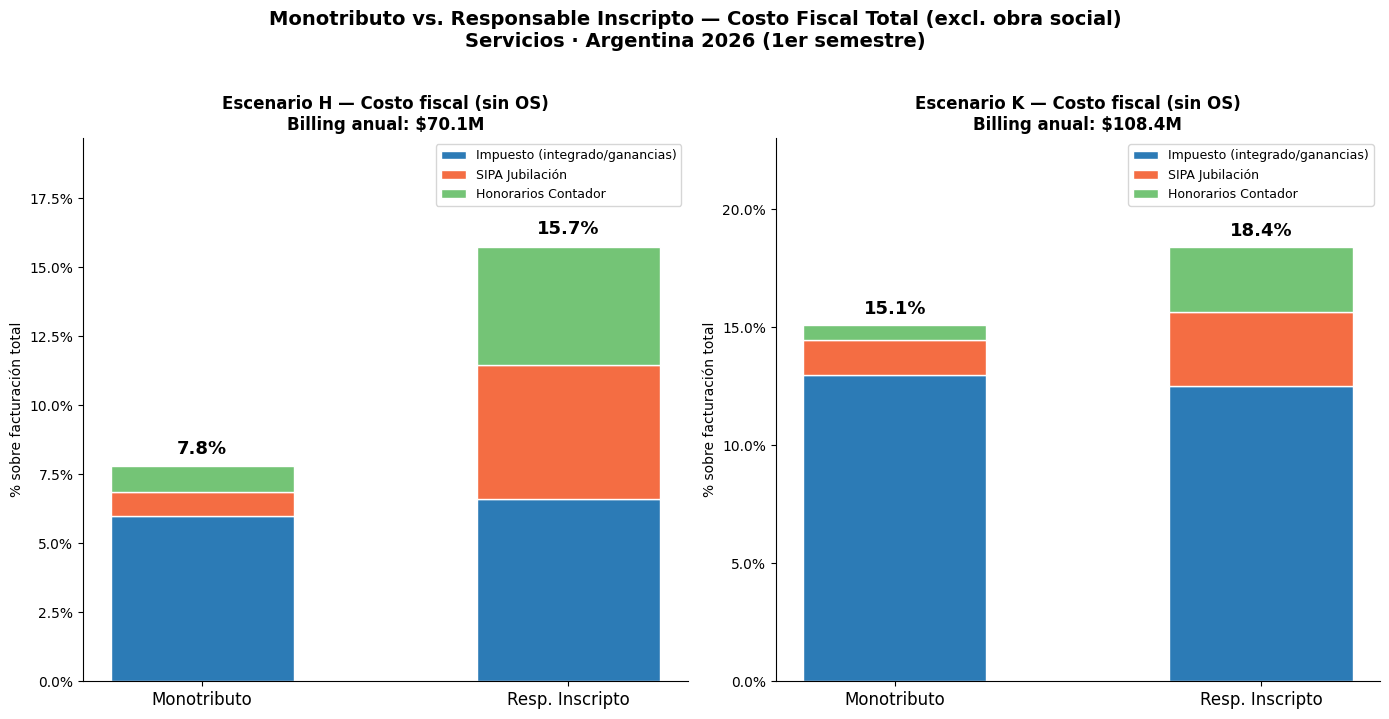

Gráfico guardado: comparativa_costo_fiscal.png


In [9]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico 1: Costo total como % del billing (sin OS)
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

COLORS = {
    'impuesto':  '#2C7BB6',  # azul
    'sipa':      '#F46D43',  # naranja
    'contador':  '#74C476',  # verde
    'os':        '#BDBDBD',  # gris (excluida)
}

scenarios = [
    ('H', res_mono_h, res_ri_h),
    ('K', res_mono_k, res_ri_k),
]

for ax, (cat, rm, rr) in zip(axes, scenarios):
    regimenes = ['Monotributo', 'Resp. Inscripto']
    impuesto_pct = [rm['pct_impuesto'], rr['pct_ganancias']]
    sipa_pct     = [rm['pct_sipa'],     rr['pct_sipa']]
    contador_pct = [rm['pct_contador'], rr['pct_contador']]

    x = np.arange(len(regimenes))
    w = 0.5

    bars_imp = ax.bar(x, impuesto_pct, w, label='Impuesto (integrado/ganancias)',
                      color=COLORS['impuesto'], edgecolor='white')
    bars_sip = ax.bar(x, sipa_pct, w, bottom=impuesto_pct,
                      label='SIPA Jubilación',
                      color=COLORS['sipa'], edgecolor='white')
    bottoms = [i + s for i, s in zip(impuesto_pct, sipa_pct)]
    bars_cnt = ax.bar(x, contador_pct, w, bottom=bottoms,
                      label='Honorarios Contador',
                      color=COLORS['contador'], edgecolor='white')

    # Etiquetas de total
    totales = [rm['pct_total_sin_os'], rr['pct_total_sin_os']]
    for i, total in enumerate(totales):
        ax.text(i, total + 0.3, f'{total:.1f}%', ha='center', va='bottom',
                fontsize=13, fontweight='bold')

    ax.set_title(f'Escenario {cat} — Costo fiscal (sin OS)\n'
                 f'Billing anual: ${MONO[cat]["billing_anual_max"]/1e6:.1f}M',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('% sobre facturación total')
    ax.set_xticks(x)
    ax.set_xticklabels(regimenes, fontsize=12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0, max(totales) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Monotributo vs. Responsable Inscripto — Costo Fiscal Total (excl. obra social)\n'
             'Servicios · Argentina 2026 (1er semestre)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparativa_costo_fiscal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparativa_costo_fiscal.png')

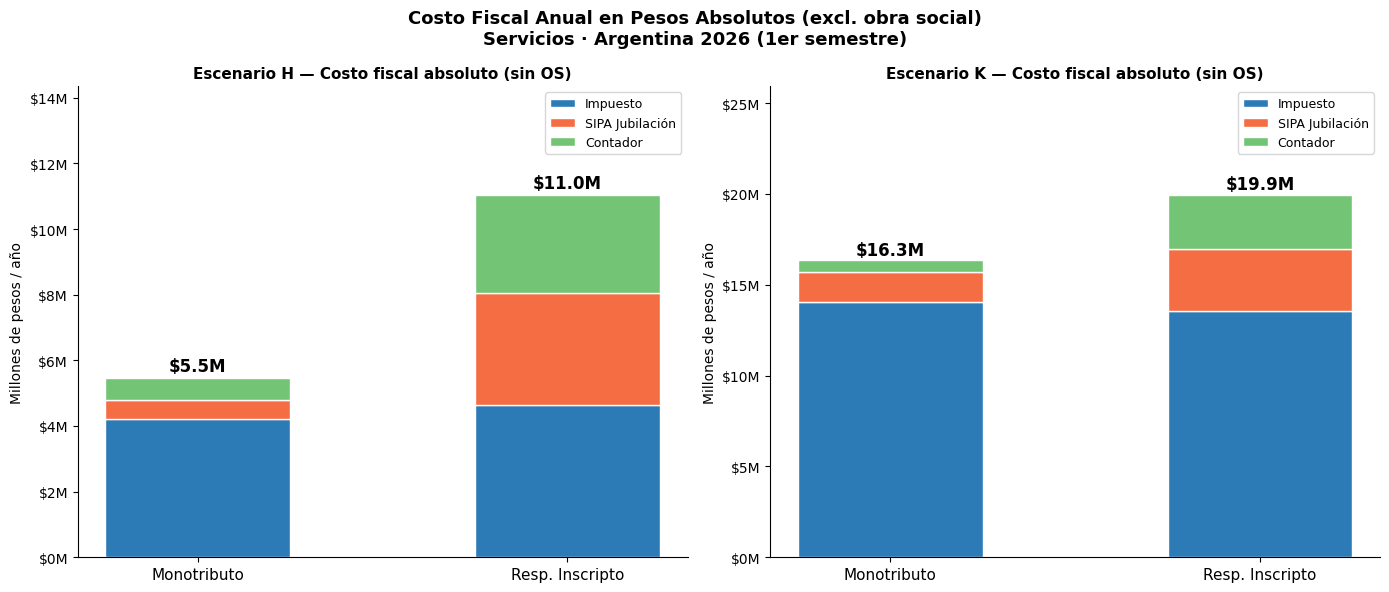

In [10]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico 2: Costo total en pesos absolutos
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (cat, rm, rr) in zip(axes, scenarios):
    regimenes = ['Monotributo', 'Resp. Inscripto']
    impuesto_abs = [rm['impuesto_integrado_anual'] / 1e6, rr['impuesto_ganancias'] / 1e6]
    sipa_abs     = [rm['sipa_jubilacion_anual'] / 1e6,    rr['autonomos_sipa_anual'] / 1e6]
    contador_abs = [rm['contador_anual'] / 1e6,           rr['contador_anual'] / 1e6]

    x = np.arange(len(regimenes))
    w = 0.5

    ax.bar(x, impuesto_abs, w, label='Impuesto', color=COLORS['impuesto'], edgecolor='white')
    ax.bar(x, sipa_abs, w, bottom=impuesto_abs, label='SIPA Jubilación',
           color=COLORS['sipa'], edgecolor='white')
    bottoms_abs = [i + s for i, s in zip(impuesto_abs, sipa_abs)]
    ax.bar(x, contador_abs, w, bottom=bottoms_abs, label='Contador',
           color=COLORS['contador'], edgecolor='white')

    totales_abs = [rm['costo_total_sin_os'] / 1e6, rr['costo_total_sin_os'] / 1e6]
    for i, total in enumerate(totales_abs):
        ax.text(i, total + 0.1, f'${total:.1f}M', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax.set_title(f'Escenario {cat} — Costo fiscal absoluto (sin OS)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Millones de pesos / año')
    ax.set_xticks(x)
    ax.set_xticklabels(regimenes, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0, max(totales_abs) * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Costo Fiscal Anual en Pesos Absolutos (excl. obra social)\n'
             'Servicios · Argentina 2026 (1er semestre)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_costo_absoluto.png', dpi=150, bbox_inches='tight')
plt.show()

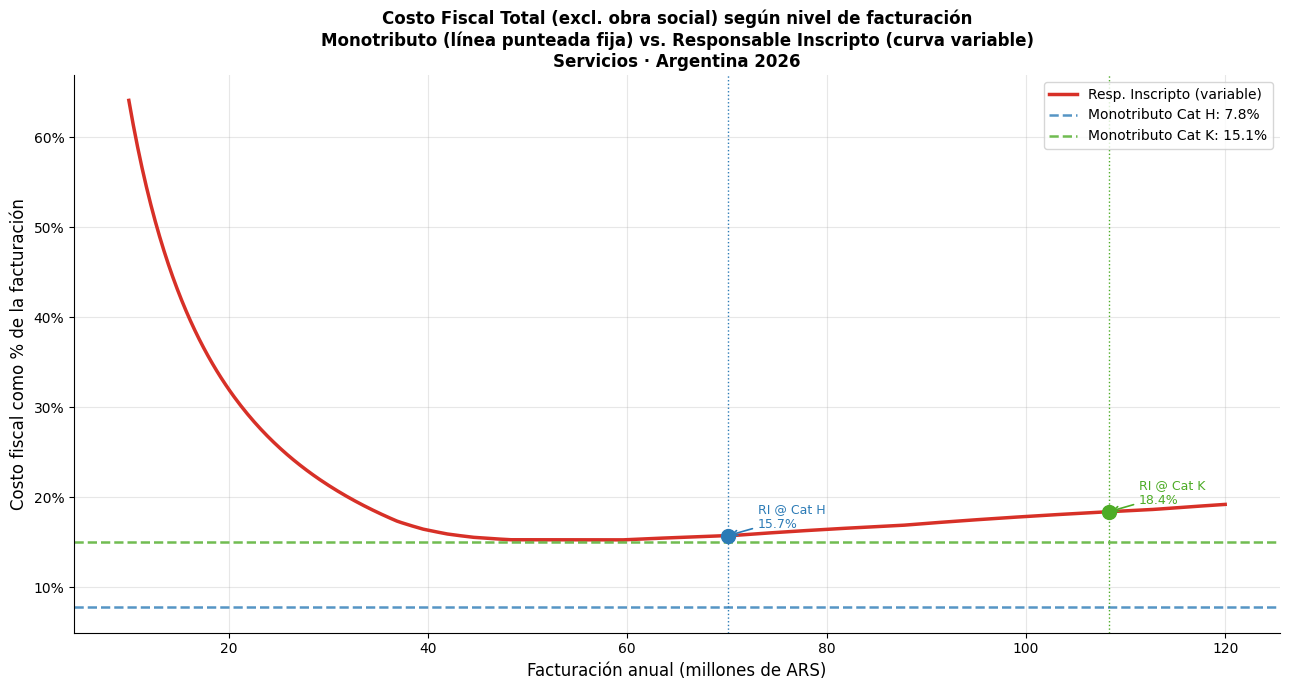

In [11]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico 3: Costo total (% billing) vs. nivel de facturación
# Muestra cómo evoluciona el costo de RI a medida que crece la facturación
# ─────────────────────────────────────────────────────────────────────
billings = np.linspace(10_000_000, 120_000_000, 500)

pct_mono_h = [res_mono_h['pct_total_sin_os']] * len(billings)  # fijo en su nivel
pct_mono_k = [res_mono_k['pct_total_sin_os']] * len(billings)  # fijo en su nivel
pct_ri = [calcular_ri(b, '')['pct_total_sin_os'] for b in billings]

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(billings / 1e6, pct_ri, color='#D73027', lw=2.5, label='Resp. Inscripto (variable)')

# Puntos de referencia Monotributo
ax.axhline(res_mono_h['pct_total_sin_os'], color='#2C7BB6',
           lw=1.8, linestyle='--', alpha=0.8,
           label=f"Monotributo Cat H: {res_mono_h['pct_total_sin_os']:.1f}%")
ax.axhline(res_mono_k['pct_total_sin_os'], color='#4DAC26',
           lw=1.8, linestyle='--', alpha=0.8,
           label=f"Monotributo Cat K: {res_mono_k['pct_total_sin_os']:.1f}%")

# Marcar los escenarios H y K en la curva RI
for cat, rm, rr, color in [('H', res_mono_h, res_ri_h, '#2C7BB6'),
                              ('K', res_mono_k, res_ri_k, '#4DAC26')]:
    b_m = rm['billing_anual'] / 1e6
    p_ri_scen = rr['pct_total_sin_os']
    ax.scatter([b_m], [p_ri_scen], s=100, color=color, zorder=5)
    ax.annotate(f"RI @ Cat {cat}\n{p_ri_scen:.1f}%",
                xy=(b_m, p_ri_scen), xytext=(b_m + 3, p_ri_scen + 0.8),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

# Línea vertical en el tope de categoría H
ax.axvline(MONO['H']['billing_anual_max'] / 1e6, color='#2C7BB6', lw=1, linestyle=':')
ax.axvline(MONO['K']['billing_anual_max'] / 1e6, color='#4DAC26', lw=1, linestyle=':')

ax.set_xlabel('Facturación anual (millones de ARS)', fontsize=12)
ax.set_ylabel('Costo fiscal como % de la facturación', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Costo Fiscal Total (excl. obra social) según nivel de facturación\n'
             'Monotributo (línea punteada fija) vs. Responsable Inscripto (curva variable)\n'
             'Servicios · Argentina 2026',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('curva_costo_vs_facturacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Resumen Ejecutivo

In [12]:
print()
print('█' * 70)
print('  RESUMEN EJECUTIVO — Monotributo vs. Responsable Inscripto')
print('  Argentina 2026 (1er semestre) · Prestación de servicios')
print('█' * 70)
print()

for cat, rm, rr in [('H', res_mono_h, res_ri_h), ('K', res_mono_k, res_ri_k)]:
    diferencia_pct  = rr['pct_total_sin_os'] - rm['pct_total_sin_os']
    diferencia_abs  = rr['costo_total_sin_os'] - rm['costo_total_sin_os']
    mas_caro        = 'RI es más caro' if diferencia_pct > 0 else 'Monotributo es más caro'

    print(f'  ┌─ ESCENARIO {cat} — Billing anual: ${rm["billing_anual"]/1e6:.1f}M '
          f'(${rm["billing_mensual"]/1e3:.0f}K/mes) ─────────────────────────')
    print(f'  │')
    print(f'  │  Facturación mensual (max):         {fmt_pesos(rm["billing_mensual"])}')
    print(f'  │')
    print(f'  │           MONOTRIBUTO    RESP. INSCRIPTO   DIFERENCIA')
    print(f'  │           ─────────────  ──────────────    ─────────────')
    print(f'  │  ANUAL:')
    print(f'  │  Impuesto  {fmt_pesos(rm["impuesto_integrado_anual"])}  {fmt_pesos(rr["impuesto_ganancias"])}  '
          f'{fmt_pesos(rr["impuesto_ganancias"] - rm["impuesto_integrado_anual"])}')
    print(f'  │  SIPA jub. {fmt_pesos(rm["sipa_jubilacion_anual"])}  {fmt_pesos(rr["autonomos_sipa_anual"])}  '
          f'{fmt_pesos(rr["autonomos_sipa_anual"] - rm["sipa_jubilacion_anual"])}')
    print(f'  │  Contador  {fmt_pesos(rm["contador_anual"])}  {fmt_pesos(rr["contador_anual"])}  '
          f'{fmt_pesos(rr["contador_anual"] - rm["contador_anual"])}')
    # Nota: OS en RI = $0 en autónomos (se paga por separado fuera del análisis)
    print(f'  │  OS (excl) {fmt_pesos(rm["obra_social_anual"])}  $               0  '
          f'[OS de RI se paga aparte]')
    print(f'  │  ─────────────────────────────────────────────────────')
    print(f'  │  TOTAL     {fmt_pesos(rm["costo_total_sin_os"])}  {fmt_pesos(rr["costo_total_sin_os"])}  '
          f'{fmt_pesos(diferencia_abs)}')
    print(f'  │  (sin OS)')
    print(f'  │')
    print(f'  │  % BILLING:    {rm["pct_total_sin_os"]:6.2f}%          {rr["pct_total_sin_os"]:6.2f}%          +{abs(diferencia_pct):.2f}pp')
    print(f'  │')
    print(f'  │  ▶ {mas_caro} en {abs(diferencia_pct):.2f} puntos porcentuales')
    print(f'  │  ▶ Diferencia absoluta anual: {fmt_pesos(abs(diferencia_abs))}')
    print(f'  │  ▶ Diferencia mensual aprox.: {fmt_pesos(abs(diferencia_abs)/12)}')
    print(f'  └─────────────────────────────────────────────────────────────────────')
    print()

print('─'*70)
print('  NOTAS Y SUPUESTOS CLAVE:')
print('─'*70)
print(f'  • Monotributo: cuotas feb 2026 (ARCA / Contablix)')
print(f'  • RI - Autónomos Cat V feb-2026: ${AUTONOMOS_CAT_V_MES:,.0f}/mes → 100% SIPA jubilación')
print(f'    La obra social del RI se paga APARTE (prepaga/OS voluntaria, excluida)')
print(f'  • RI - Ganancias: escala progresiva 5%-35% (1er sem 2026, Art. 94 LIG)')
print(f'  • RI - Deducciones personales: MNI ${MNI_ANUAL/1e6:.2f}M + '
      f'Ded.Especial ${DED_ESPECIAL_ANUAL/1e6:.0f}M = ${DEDUCCIONES_PERSONALES/1e6:.2f}M/año')
print(f'  • RI - Gastos deducibles: 20% de la facturación')
print(f'  • RI - IVA (21%): NEUTRO — clientes RI que acreditan (B2B)')
print(f'  • Contador Monotributo: ${MONO_CONTADOR_MES:,}/mes (${MONO_CONTADOR_MES*12:,}/año)')
print(f'  • Contador RI: ${RI_CONTADOR_MES:,}/mes (${RI_CONTADOR_ANUAL:,}/año) — '
      f'rango razonable $200k-$300k/mes')
print(f'  • Obra social EXCLUIDA del total en ambos regímenes')
print(f'    - Monotributo: excluye la cuota de obra social incluida en la categoría')
print(f'    - RI: la obra social no está en los autónomos; se paga por separado')
print(f'  • Ingresos Brutos (provincial): EXCLUIDO (aplica a ambos, no altera diferencia)')
print(f'  • Profesional soltero sin cargas de familia · Actividad: servicios')


██████████████████████████████████████████████████████████████████████
  RESUMEN EJECUTIVO — Monotributo vs. Responsable Inscripto
  Argentina 2026 (1er semestre) · Prestación de servicios
██████████████████████████████████████████████████████████████████████

  ┌─ ESCENARIO H — Billing anual: $70.1M ($5843K/mes) ─────────────────────────
  │
  │  Facturación mensual (max):         $      5,842,784
  │
  │           MONOTRIBUTO    RESP. INSCRIPTO   DIFERENCIA
  │           ─────────────  ──────────────    ─────────────
  │  ANUAL:
  │  Impuesto  $      4,206,804  $      4,635,071  $        428,267
  │  SIPA jub. $        591,528  $      3,407,208  $      2,815,680
  │  Contador  $        660,000  $      3,000,000  $      2,340,000
  │  OS (excl) $        569,832  $               0  [OS de RI se paga aparte]
  │  ─────────────────────────────────────────────────────
  │  TOTAL     $      5,458,332  $     11,042,279  $      5,583,947
  │  (sin OS)
  │
  │  % BILLING:      7.79%         

In [13]:
# ─────────────────────────────────────────────────────────────────────
# Tabla síntesis final (formato limpio)
# ─────────────────────────────────────────────────────────────────────
sintesis = []
for cat, rm, rr in [('H', res_mono_h, res_ri_h), ('K', res_mono_k, res_ri_k)]:
    for regimen, res in [('Monotributo', rm), ('Resp. Inscripto', rr)]:
        if regimen == 'Monotributo':
            imp = res['impuesto_integrado_anual']
            sipa = res['sipa_jubilacion_anual']
            os_ = res['obra_social_anual']
        else:
            imp = res['impuesto_ganancias']
            sipa = res['autonomos_sipa_anual']
            os_ = res['autonomos_salud_anual']
        sintesis.append({
            'Escenario': f'Cat {cat}',
            'Régimen': regimen,
            'Billing anual': res['billing_anual'],
            'Billing mensual': res['billing_mensual'],
            'Impuesto anual': imp,
            '% Impuesto': imp / res['billing_anual'] * 100,
            'SIPA jubilación anual': sipa,
            '% SIPA': sipa / res['billing_anual'] * 100,
            'OS/Salud anual (excluida)': os_,
            '% OS': os_ / res['billing_anual'] * 100,
            'Contador anual': res['contador_anual'],
            '% Contador': res['contador_anual'] / res['billing_anual'] * 100,
            'TOTAL (sin OS) anual': res['costo_total_sin_os'],
            '% TOTAL (sin OS)': res['pct_total_sin_os'],
            'TOTAL (con OS) anual': res['costo_total_con_os'],
            '% TOTAL (con OS)': res['pct_total_con_os'],
        })

df_sintesis = pd.DataFrame(sintesis).set_index(['Escenario', 'Régimen'])
print('=== TABLA SÍNTESIS FINAL ===')
display(df_sintesis)

=== TABLA SÍNTESIS FINAL ===


Billing anual  Billing mensual  Impuesto anual  % Impuesto  SIPA jubilación anual  % SIPA  \
Escenario Régimen                                                                                                      
Cat H     Monotributo           70113407        5,842,784       4,206,804           6                591,528       1   
          Resp. Inscripto       70113407        5,842,784       4,635,071           7              3,407,208       5   
Cat K     Monotributo          108357084        9,029,757      14,054,556          13              1,623,156       1   
          Resp. Inscripto      108357084        9,029,757      13,539,495          12              3,407,208       3   

                           OS/Salud anual (excluida)  % OS  Contador anual  % Contador  TOTAL (sin OS) anual  \
Escenario Régimen                                                                                              
Cat H     Monotributo                        569,832     1          660000           1             5,458,332   
          Resp. Inscripto                          0     0         3000000           4            11,042,279   
Cat K     Monotributo                        902,556     1          660000           1            16,337,712   
          Resp. Inscripto                          0     0         3000000           3            19,946,703   

                           % TOTAL (sin OS)  TOTAL (con OS) anual  % TOTAL (con OS)  
Escenario Régimen                                                                    
Cat H     Monotributo                     8             6,028,164                 9  
          Resp. Inscripto                16            11,042,279                16  
Cat K     Monotributo                    15            17,240,268                16  
          Resp. Inscripto                18            19,946,703                18

---
## 8. Conclusiones

### Hallazgos principales (1er semestre 2026, servicios)

| Escenario | Monotributo (% billing) | RI (% billing) | Diferencia RI vs. Mono |
|-----------|------------------------|----------------|------------------------|
| Cat H (~$70M/año) | **7,8%** | **15,8%** | **RI +8,0 pp más caro** |
| Cat K (~$108M/año) | **15,1%** | **18,4%** | **RI +3,4 pp más caro** |

### Factores que explican las diferencias

1. **SIPA autónomos Cat V es alto en relación a ingresos medios**:  
   En RI, el aporte fijo de $283.934/mes (~$3,4M/año) es el costo previsional base.  
   En Monotributo Cat H, el SIPA es apenas ~$49.294/mes (~$591.528/año) — **5,8x menos**.  
   Esta es la mayor diferencia en el escenario H.

2. **El impuesto integrado del monotributo Cat H es muy bajo**:  
   Representa apenas ~6% del billing, mientras que Ganancias en RI alcanza ~6,6%.  
   La diferencia de impuesto puro es pequeña; la brecha viene principalmente de SIPA y contador.

3. **El contador en RI cuesta ~4,5x más**:  
   $250.000/mes vs. $55.000/mes. En escenario H esto representa 4,3% del billing vs. 0,9%.

4. **La brecha se achica en Cat K**:  
   A $108M/año, el impuesto integrado del monotributo sube a ~$14M/año (13% del billing),  
   mientras que Ganancias en RI ronda ~$13,5M/año (12,5%). El impuesto se equipara;  
   la diferencia restante viene del SIPA fijo y el contador.

### Diferencia en tratamiento de obra social

| Concepto | Monotributo | Resp. Inscripto |
|---|---|---|
| Obra social incluida en cuota mensual | Sí (componente explícito) | No |
| Cómo se paga la obra social | Dentro de la cuota fija | Por separado (prepaga / OS voluntaria) |
| Costo aproximado (si se redirige a prepaga) | Excluido del análisis | Excluido del análisis |

> Ambos regímenes permiten redirigir la cobertura a una prepaga. En monotributo, el aporte de obra social está incluido en la cuota mensual (excluido en este análisis). En RI, el costo de salud es completamente independiente.

### Consideraciones adicionales (fuera del scope numérico)

- **IVA y competitividad con consumidores finales**: Si el prestador tiene clientes que son consumidores finales (personas humanas), la obligación de cargar IVA (21%) sobre los honorarios encarece el servicio para esos clientes en un 21%. En monotributo, los precios son finales sin IVA adicional.

- **Límite de facturación**: El monotributo tiene un techo (~$108M/año en Cat K). Al superarlo, la adhesión al RI se vuelve **obligatoria** independientemente de la comparación de costos.

- **Ingresos Brutos provinciales**: Se aplica a ambos regímenes (típicamente 2,5-4% en CABA/PBA para servicios). No altera la comparativa relativa entre regímenes.

- **Complejidad administrativa del RI**: DDJJ IVA mensual, 10 anticipos de Ganancias bimestrales, DDJJ anual de Ganancias, gestión autónomos mensual. Esto justifica el mayor honorario del contador.

- **Sensibilidad al honorario del contador RI**:  
  Si cobra $200.000/mes → RI baja ~0,7pp sobre el billing.  
  Si cobra $300.000/mes → RI sube ~0,7pp sobre el billing.

### Recomendación

> Para un prestador de servicios con facturación dentro de la Categoría H (~$70M/año), el **Monotributo es significativamente más conveniente**: ahorra ~8 puntos porcentuales del billing (~$5.5-6M/año). A medida que la facturación se acerca al máximo de la Categoría K (~$108M/año), la brecha se reduce a ~3-4 puntos, pero el Monotributo continúa siendo más económico mientras la facturación no supere el tope de $108M/año.

---
## 9. Análisis con 45% de Costos Deducibles

A diferencia del escenario base (20%), un profesional con estructura de costos más alta —equipamiento, subcontrataciones, alquileres, insumos— puede deducir hasta el **45% de su facturación** en Ganancias. Esto reduce significativamente la Ganancia Neta Imponible y, con ella, el impuesto resultante.

> **¿Cuándo aplica el 45%?** Típicamente en actividades con: alquiler de espacio físico, personal auxiliar, tecnología/licencias, viáticos, subcontratación de servicios complementarios. El monotributo **no se ve afectado**: la cuota es fija independientemente de los costos reales.

In [14]:
# ─────────────────────────────────────────────────────────────────────
# Escenarios RI con 45% de gastos deducibles
# ─────────────────────────────────────────────────────────────────────
res_ri_h45 = calcular_ri(MONO['H']['billing_anual_max'], 'H', pct_gastos=0.45)
res_ri_k45 = calcular_ri(MONO['K']['billing_anual_max'], 'K', pct_gastos=0.45)

for r in [res_ri_h45, res_ri_k45]:
    print(f"{'='*60}")
    print(f" RESPONSABLE INSCRIPTO — ESCENARIO {r['categoria']} (gastos {r['pct_gastos']:.0%})")
    print(f"{'='*60}")
    print(f"   45% gastos profesionales:          {fmt_pesos(r['gastos_deducibles_anual'])}")
    print(f"   Honorarios contador:               {fmt_pesos(r['contador_anual'])}")
    print(f"   Aportes autónomos Cat V:           {fmt_pesos(r['autonomos_total_anual'])}")
    print(f"   Deducciones personales (MNI+DE):   {fmt_pesos(r['deducciones_personales'])}")
    print(f"   ─────────────────────────────────")
    print(f"   Ganancia Neta Imponible:           {fmt_pesos(r['gni'])}")
    print()
    print(f"   Impuesto a las Ganancias:          {fmt_pesos(r['impuesto_ganancias'])}  ({r['pct_ganancias']:.2f}%)")
    print(f"   SIPA jubilación (100% autónomos):  {fmt_pesos(r['autonomos_sipa_anual'])}  ({r['pct_sipa']:.2f}%)")
    print(f"   Honorarios contador:               {fmt_pesos(r['contador_anual'])}  ({r['pct_contador']:.2f}%)")
    print(f"   COSTO TOTAL (sin OS):              {fmt_pesos(r['costo_total_sin_os'])}  → {r['pct_total_sin_os']:.2f}%")
    print()

 RESPONSABLE INSCRIPTO — ESCENARIO H (gastos 45%)
   45% gastos profesionales:          $     31,551,033
   Honorarios contador:               $      3,000,000
   Aportes autónomos Cat V:           $      3,407,208
   Deducciones personales (MNI+DE):   $     23,183,112
   ─────────────────────────────────
   Ganancia Neta Imponible:           $      8,972,054

   Impuesto a las Ganancias:          $        965,803  (1.38%)
   SIPA jubilación (100% autónomos):  $      3,407,208  (4.86%)
   Honorarios contador:               $      3,000,000  (4.28%)
   COSTO TOTAL (sin OS):              $      7,373,011  → 10.52%

 RESPONSABLE INSCRIPTO — ESCENARIO K (gastos 45%)
   45% gastos profesionales:          $     48,760,688
   Honorarios contador:               $      3,000,000
   Aportes autónomos Cat V:           $      3,407,208
   Deducciones personales (MNI+DE):   $     23,183,112
   ─────────────────────────────────
   Ganancia Neta Imponible:           $     30,006,076

   Impuesto a la

In [15]:
# ─────────────────────────────────────────────────────────────────────
# Tabla comparativa: Monotributo vs. RI con 20% y 45% de gastos
# ─────────────────────────────────────────────────────────────────────
filas = []
for cat, rm, rr20, rr45 in [
    ('H', res_mono_h, res_ri_h, res_ri_h45),
    ('K', res_mono_k, res_ri_k, res_ri_k45),
]:
    for concepto, v_mono, v_ri20, v_ri45 in [
        ('Billing anual',              rm['billing_anual'],          rr20['billing_anual'],         rr45['billing_anual']),
        ('Gastos deducibles (anual)',   rm['billing_anual']*0,        rr20['gastos_deducibles_anual'],rr45['gastos_deducibles_anual']),
        ('Ganancia Neta Imponible',    0,                             rr20['gni'],                   rr45['gni']),
        ('Impuesto (integrado/Ganancias)', rm['impuesto_integrado_anual'], rr20['impuesto_ganancias'], rr45['impuesto_ganancias']),
        ('SIPA jubilación',            rm['sipa_jubilacion_anual'],   rr20['autonomos_sipa_anual'],  rr45['autonomos_sipa_anual']),
        ('Honorarios contador',        rm['contador_anual'],          rr20['contador_anual'],        rr45['contador_anual']),
        ('TOTAL (sin OS)',             rm['costo_total_sin_os'],      rr20['costo_total_sin_os'],    rr45['costo_total_sin_os']),
        ('% del billing',             rm['pct_total_sin_os'],        rr20['pct_total_sin_os'],      rr45['pct_total_sin_os']),
    ]:
        filas.append({
            'Escenario': f'Cat {cat}',
            'Concepto': concepto,
            'Monotributo': v_mono,
            'RI — 20% gastos': v_ri20,
            'RI — 45% gastos': v_ri45,
        })

df_comp_45 = pd.DataFrame(filas).set_index(['Escenario', 'Concepto'])
print('=== TABLA COMPARATIVA: Monotributo vs. RI (20% y 45% gastos deducibles) ===')
display(df_comp_45)

=== TABLA COMPARATIVA: Monotributo vs. RI (20% y 45% gastos deducibles) ===


Monotributo  RI — 20% gastos  RI — 45% gastos
Escenario Concepto                                                                     
Cat H     Billing anual                    70,113,407       70,113,407       70,113,407
          Gastos deducibles (anual)                 0       14,022,681       31,551,033
          Ganancia Neta Imponible                   0       26,500,406        8,972,054
          Impuesto (integrado/Ganancias)    4,206,804        4,635,071          965,803
          SIPA jubilación                     591,528        3,407,208        3,407,208
          Honorarios contador                 660,000        3,000,000        3,000,000
          TOTAL (sin OS)                    5,458,332       11,042,279        7,373,011
          % del billing                             8               16               11
Cat K     Billing anual                   108,357,084      108,357,084      108,357,084
          Gastos deducibles (anual)                 0       21,671,417       48,760,688
          Ganancia Neta Imponible                   0       57,095,347       30,006,076
          Impuesto (integrado/Ganancias)   14,054,556       13,539,495        5,561,602
          SIPA jubilación                   1,623,156        3,407,208        3,407,208
          Honorarios contador                 660,000        3,000,000        3,000,000
          TOTAL (sin OS)                   16,337,712       19,946,703       11,968,810
          % del billing                            15               18               11

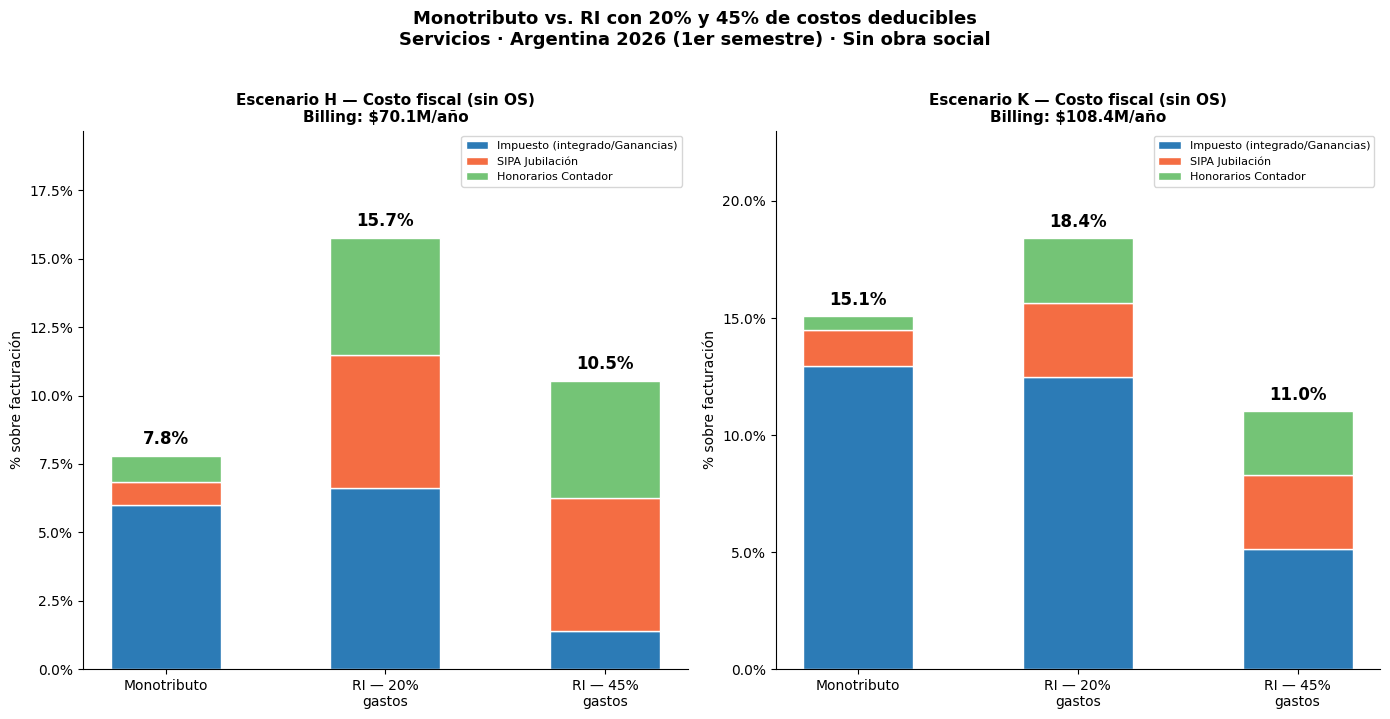

Gráfico guardado: comparativa_45pct_gastos.png


In [16]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico: comparación Monotributo vs. RI 20% vs. RI 45%
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

COLOR_MONO  = '#2C7BB6'   # azul
COLOR_RI20  = '#D73027'   # rojo
COLOR_RI45  = '#FC8D59'   # naranja

scenarios_45 = [
    ('H', res_mono_h, res_ri_h, res_ri_h45),
    ('K', res_mono_k, res_ri_k, res_ri_k45),
]

for ax, (cat, rm, rr20, rr45) in zip(axes, scenarios_45):
    regimenes = ['Monotributo', 'RI — 20%\ngastos', 'RI — 45%\ngastos']
    
    # Impuesto
    imp = [rm['pct_impuesto'], rr20['pct_ganancias'], rr45['pct_ganancias']]
    # SIPA
    sipa = [rm['pct_sipa'], rr20['pct_sipa'], rr45['pct_sipa']]
    # Contador
    cnt = [rm['pct_contador'], rr20['pct_contador'], rr45['pct_contador']]

    x = np.arange(len(regimenes))
    w = 0.5

    b1 = ax.bar(x, imp,  w, label='Impuesto (integrado/Ganancias)', color='#2C7BB6', edgecolor='white')
    b2 = ax.bar(x, sipa, w, bottom=imp, label='SIPA Jubilación', color='#F46D43', edgecolor='white')
    bottoms = [i+s for i,s in zip(imp, sipa)]
    b3 = ax.bar(x, cnt,  w, bottom=bottoms, label='Honorarios Contador', color='#74C476', edgecolor='white')

    totales = [rm['pct_total_sin_os'], rr20['pct_total_sin_os'], rr45['pct_total_sin_os']]
    for i, total in enumerate(totales):
        ax.text(i, total + 0.3, f'{total:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_title(f'Escenario {cat} — Costo fiscal (sin OS)\nBilling: ${MONO[cat]["billing_anual_max"]/1e6:.1f}M/año',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('% sobre facturación')
    ax.set_xticks(x)
    ax.set_xticklabels(regimenes, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, max(totales) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Monotributo vs. RI con 20% y 45% de costos deducibles\n'
             'Servicios · Argentina 2026 (1er semestre) · Sin obra social',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparativa_45pct_gastos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparativa_45pct_gastos.png')

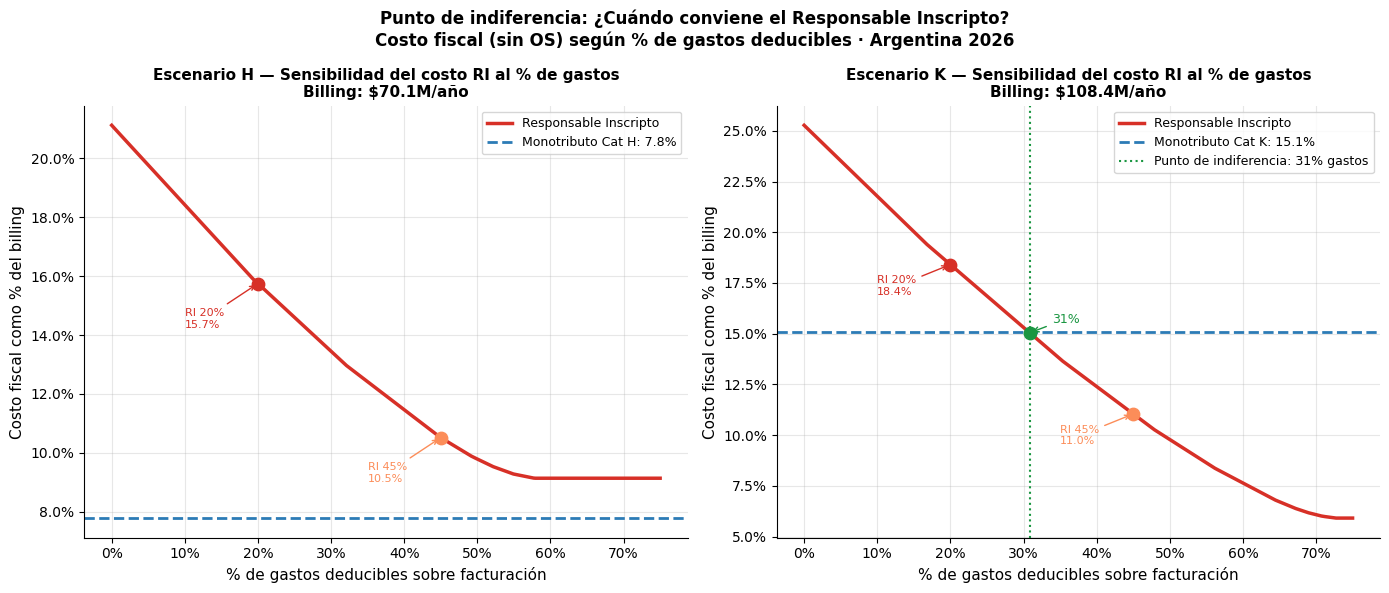

In [17]:
# ─────────────────────────────────────────────────────────────────────
# Curva de sensibilidad: costo total RI en función de % de gastos
# Para ambos escenarios H y K — compara vs. techo fijo del Monotributo
# ─────────────────────────────────────────────────────────────────────
pcts = np.linspace(0, 0.75, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (cat, rm) in zip(axes, [('H', res_mono_h), ('K', res_mono_k)]):
    billing = MONO[cat]['billing_anual_max']
    ri_pcts = [calcular_ri(billing, cat, p)['pct_total_sin_os'] for p in pcts]
    mono_pct = rm['pct_total_sin_os']

    ax.plot(pcts * 100, ri_pcts, color='#D73027', lw=2.5, label='Responsable Inscripto')
    ax.axhline(mono_pct, color='#2C7BB6', lw=2, linestyle='--',
               label=f'Monotributo Cat {cat}: {mono_pct:.1f}%')

    # Punto de indiferencia: dónde RI = Monotributo
    cross_pct = None
    for p, v in zip(pcts, ri_pcts):
        if v <= mono_pct:
            cross_pct = p
            break
    if cross_pct is not None:
        cross_val = calcular_ri(billing, cat, cross_pct)['pct_total_sin_os']
        ax.axvline(cross_pct * 100, color='#1A9641', lw=1.5, linestyle=':',
                   label=f'Punto de indiferencia: {cross_pct:.0%} gastos')
        ax.scatter([cross_pct * 100], [cross_val], s=80, color='#1A9641', zorder=5)
        ax.annotate(f'{cross_pct:.0%}',
                    xy=(cross_pct*100, cross_val),
                    xytext=(cross_pct*100 + 3, cross_val + 0.5),
                    fontsize=9, color='#1A9641',
                    arrowprops=dict(arrowstyle='->', color='#1A9641', lw=1))

    # Marcar los escenarios 20% y 45%
    for g, color, lbl in [(0.20, '#D73027', '20%'), (0.45, '#FC8D59', '45%')]:
        v = calcular_ri(billing, cat, g)['pct_total_sin_os']
        ax.scatter([g*100], [v], s=80, color=color, zorder=6)
        ax.annotate(f'RI {lbl}\n{v:.1f}%', xy=(g*100, v),
                    xytext=(g*100 - 10, v - 1.5),
                    fontsize=8, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=1))

    ax.set_xlabel('% de gastos deducibles sobre facturación', fontsize=11)
    ax.set_ylabel('Costo fiscal como % del billing', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(f'Escenario {cat} — Sensibilidad del costo RI al % de gastos\n'
                 f'Billing: ${billing/1e6:.1f}M/año', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Punto de indiferencia: ¿Cuándo conviene el Responsable Inscripto?\n'
             'Costo fiscal (sin OS) según % de gastos deducibles · Argentina 2026',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sensibilidad_pct_gastos.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ─────────────────────────────────────────────────────────────────────
# Resumen ejecutivo comparativo: 20% vs. 45% de costos deducibles
# ─────────────────────────────────────────────────────────────────────
print()
print('█' * 72)
print('  RESUMEN: Impacto de pasar de 20% a 45% de gastos deducibles en RI')
print('  Argentina 2026 (1er semestre) · Prestación de servicios')
print('█' * 72)
print()

header = f"  {'Escenario':<12} {'Monotributo':>14} {'RI — 20% gastos':>18} {'RI — 45% gastos':>18}"
print(header)
print('  ' + '─' * (len(header) - 2))

for cat, rm, rr20, rr45 in [
    ('H ($70.1M)', res_mono_h, res_ri_h, res_ri_h45),
    ('K ($108.4M)', res_mono_k, res_ri_k, res_ri_k45),
]:
    delta_20 = rr20['pct_total_sin_os'] - rm['pct_total_sin_os']
    delta_45 = rr45['pct_total_sin_os'] - rm['pct_total_sin_os']
    marker_20 = '▲' if delta_20 > 0 else '▼'
    marker_45 = '▲' if delta_45 > 0 else '▼'

    print(f"  {'Costo % billing':<12}  {rm['pct_total_sin_os']:>12.2f}%  {rr20['pct_total_sin_os']:>16.2f}%  {rr45['pct_total_sin_os']:>16.2f}%   ← Cat {cat[:1]}")
    print(f"  {'vs. Mono':<12}  {'—':>14}  {marker_20} {abs(delta_20):>13.2f}pp  {marker_45} {abs(delta_45):>13.2f}pp")
    print(f"  {'Costo anual':<12}  {fmt_pesos(rm['costo_total_sin_os']):>14}  {fmt_pesos(rr20['costo_total_sin_os']):>18}  {fmt_pesos(rr45['costo_total_sin_os']):>18}")
    print(f"  {'Ganancias':<12}  {fmt_pesos(rm['impuesto_integrado_anual']):>14}  {fmt_pesos(rr20['impuesto_ganancias']):>18}  {fmt_pesos(rr45['impuesto_ganancias']):>18}")
    print(f"  {'GNI':<12}  {'n/a':>14}  {fmt_pesos(rr20['gni']):>18}  {fmt_pesos(rr45['gni']):>18}")
    ahorro = rr20['costo_total_sin_os'] - rr45['costo_total_sin_os']
    print(f"  {'Ahorro 45%':<12}  {'':>14}  {'':>18}  {fmt_pesos(ahorro):>18}  ← vs. RI 20%")
    print()

# Punto de indiferencia
print('─' * 72)
print('  PUNTO DE INDIFERENCIA (RI = Monotributo en costo fiscal):')
print('─' * 72)
for cat, rm in [('H', res_mono_h), ('K', res_mono_k)]:
    billing = MONO[cat]['billing_anual_max']
    mono_pct = rm['pct_total_sin_os']
    for p_int in range(0, 76):
        p = p_int / 100
        ri_pct = calcular_ri(billing, cat, p)['pct_total_sin_os']
        if ri_pct <= mono_pct:
            print(f"  Escenario {cat}: RI se vuelve más barato con ≥ {p:.0%} de gastos deducibles")
            print(f"    (Monotributo: {mono_pct:.2f}% | RI @ {p:.0%} gastos: {ri_pct:.2f}%)")
            break
    else:
        print(f"  Escenario {cat}: RI nunca es más barato dentro del rango 0-75%")
print()


████████████████████████████████████████████████████████████████████████
  RESUMEN: Impacto de pasar de 20% a 45% de gastos deducibles en RI
  Argentina 2026 (1er semestre) · Prestación de servicios
████████████████████████████████████████████████████████████████████████

  Escenario       Monotributo    RI — 20% gastos    RI — 45% gastos
  ─────────────────────────────────────────────────────────────────
  Costo % billing          7.79%             15.75%             10.52%   ← Cat H
  vs. Mono                   —  ▲          7.96pp  ▲          2.73pp
  Costo anual   $      5,458,332    $     11,042,279    $      7,373,011
  Ganancias     $      4,206,804    $      4,635,071    $        965,803
  GNI                      n/a    $     26,500,406    $      8,972,054
  Ahorro 45%                                          $      3,669,268  ← vs. RI 20%

  Costo % billing         15.08%             18.41%             11.05%   ← Cat K
  vs. Mono                   —  ▲          3.33pp  ▼    

---
## 10. Conclusiones: Impacto de Mayores Costos Deducibles

### Efecto sobre el Responsable Inscripto

Con el **45% de gastos deducibles**, el Impuesto a las Ganancias cae drásticamente por la reducción de la Ganancia Neta Imponible:

| Escenario | GNI al 20% gastos | GNI al 45% gastos | Reducción GNI |
|---|---|---|---|
| Cat H (~$70M) | ~$26,5M | ~$9,0M | **-66%** |
| Cat K (~$108M) | ~$57,1M | ~$30,0M | **-47%** |

### Comparativa final: los 4 escenarios

| Escenario | Monotributo | RI — 20% gastos | RI — 45% gastos |
|---|---|---|---|
| Cat H | **7,79%** | 15,75% (+8pp) | **~10,5%** (+2,7pp) |
| Cat K | **15,08%** | 18,42% (+3,3pp) | **~11,0%** (-4pp) ← RI conveniene |

### Hallazgo clave: punto de quiebre

> A mayor porcentaje de gastos deducibles, el RI se vuelve más competitivo porque Ganancias aplica sobre una base mucho menor, mientras que el Monotributo paga su cuota fija independientemente de los costos reales.

- **En Cat H**: con ~45% de gastos, el RI sigue siendo más caro pero la brecha se reduce de 8pp a ~2,7pp.
- **En Cat K**: con gastos suficientemente altos, **el RI puede ser más conveniente que el Monotributo**. El punto de indiferencia (RI = Monotributo en costo fiscal) se alcanza alrededor del **~47-50% de gastos deducibles**.

### Recomendación actualizada

| Perfil del profesional | Régimen recomendado |
|---|---|
| Pocos gastos (20-30%), billing en zona Cat H | **Monotributo** — ventaja significativa |
| Pocos gastos (20-30%), billing en zona Cat K | **Monotributo** — ventaja moderada |
| Altos gastos (45%+), billing en zona Cat H | **Monotributo** — ventaja se reduce, pero persiste |
| Altos gastos (~47-50%+), billing en zona Cat K | **RI puede convenir** — Ganancias baja lo suficiente |

> La estructura real de costos es el factor determinante. Un profesional con empleados, alquiler de oficina, equipamiento y subcontrataciones puede llegar a porcentajes de gastos deducibles donde el RI se vuelve ventajoso, especialmente en los tramos de facturación más altos.

---
## 11. Análisis B2B vs. B2C: Impacto del IVA sobre el Costo Fiscal Total

### Marco conceptual corregido

En B2C, el IVA que el profesional cobra al cliente lo **remite a ARCA**: no lo puede retener. Por eso, al comparar con el mismo total facturado al cliente, ese IVA es un costo real.

| | Monotributo | RI — Clientes B2B | RI — Clientes B2C |
|---|---|---|---|
| Total que paga el cliente | $108M | $108M net + 21% IVA = $130.7M | $108M (IVA incluido) |
| Ingreso neto del profesional | $108M | $108M (IVA neutro) | $108M ÷ 1,21 = **$89,6M** |
| IVA como costo fiscal | No aplica | No (cliente RI lo recupera) | **Sí** — IVA neto va a ARCA |
| Costo total correcto | cuota + SIPA + cnt | Ganancias + SIPA + cnt | **IVA neto + Ganancias + SIPA + cnt** |

### Nota importante sobre B2B
Para B2B, la comparación natural es a **igual precio neto al cliente** ($108M). El IVA es neutral porque el cliente lo recupera. Para B2C, la comparación es a **igual total al cliente** ($108M con IVA incluido), y el IVA neto es un costo real del régimen.

In [19]:
# ─────────────────────────────────────────────────────────────────────
# Funciones corregidas para B2B y B2C
# ─────────────────────────────────────────────────────────────────────

IVA_RATE = 0.21

def calcular_ri_b2b(billing_neto, cat, pct_gastos):
    """
    B2B: el cliente RI recupera el IVA. El profesional actúa sobre
    el billing_neto como si fuera Monotributo. IVA neutro.
    Denominador para el %: billing_neto (precio neto que paga el cliente).
    """
    r = calcular_ri(billing_neto, cat, pct_gastos)
    return {
        **r,
        'regimen': 'RI B2B',
        'tipo_cliente': 'B2B',
        'total_facturado': billing_neto,   # precio efectivo para el cliente
        'net_fee': billing_neto,
        'iva_neto': 0,                      # IVA neutro para el profesional
        'costo_total': r['costo_total_sin_os'],
        'sipa_anual': r['autonomos_sipa_anual'],
        'pct_costo': r['pct_total_sin_os'],
    }

def calcular_ri_b2c(total_facturado_cliente, cat, pct_gastos):
    """
    B2C: el consumidor final no puede recuperar el IVA.
    Fijamos el total que paga el consumidor = billing de referencia ($108M o $70M).
    El ingreso neto del profesional = total / 1,21.
    El IVA neto (IVA débito - IVA crédito sobre gastos) va a ARCA → es un costo.
    IVA crédito simplificado = gastos_deducibles × 21%
    (asume que todos los gastos deducibles tienen IVA).
    """
    net_fee = total_facturado_cliente / (1 + IVA_RATE)
    iva_debito = total_facturado_cliente - net_fee          # = net_fee × 21%
    gastos_deducibles = net_fee * pct_gastos
    iva_credito = gastos_deducibles * IVA_RATE              # IVA recuperable de gastos
    iva_neto = iva_debito - iva_credito                     # lo que va efectivamente a ARCA

    autonomos_anual = AUTONOMOS_CAT_V_MES * 12
    gni = max(net_fee - gastos_deducibles - RI_CONTADOR_ANUAL
              - autonomos_anual - DEDUCCIONES_PERSONALES, 0)
    impuesto_ganancias = calcular_ganancias(gni)
    sipa_anual = autonomos_anual   # 100% de aportes (SIPA + salud, como en RI base)
    costo_fiscal_total = iva_neto + impuesto_ganancias + sipa_anual + RI_CONTADOR_ANUAL

    return {
        'regimen': 'RI B2C', 'tipo_cliente': 'B2C', 'categoria': cat,
        'pct_gastos': pct_gastos,
        'total_facturado': total_facturado_cliente,
        'net_fee': net_fee,
        'iva_debito': iva_debito,
        'iva_credito': iva_credito,
        'iva_neto': iva_neto,
        'gastos_deducibles': gastos_deducibles,
        'gni': gni,
        'impuesto_ganancias': impuesto_ganancias,
        'sipa_anual': sipa_anual,
        'contador_anual': RI_CONTADOR_ANUAL,
        'costo_total': costo_fiscal_total,
        'pct_costo': costo_fiscal_total / total_facturado_cliente * 100,
        'pct_iva_neto': iva_neto / total_facturado_cliente * 100,
        'pct_ganancias': impuesto_ganancias / total_facturado_cliente * 100,
        'pct_sipa': sipa_anual / total_facturado_cliente * 100,
        'pct_contador': RI_CONTADOR_ANUAL / total_facturado_cliente * 100,
    }

billing_h = MONO['H']['billing_anual_max']
billing_k = MONO['K']['billing_anual_max']

# ── Verificación rápida ──
print("Verificación de cálculos B2C (IVA neto incluido en costo):")
print()
for cat, billing in [('H', billing_h), ('K', billing_k)]:
    for g in [0.20, 0.45]:
        r = calcular_ri_b2c(billing, cat, g)
        print(f"Cat {cat} | gastos {g:.0%} | IVA neto: {fmt_pesos(r['iva_neto'])} "
              f"({r['pct_iva_neto']:.1f}%) | Ganancias: {fmt_pesos(r['impuesto_ganancias'])} "
              f"| Total: {fmt_pesos(r['costo_total'])} = {r['pct_costo']:.2f}%")


Verificación de cálculos B2C (IVA neto incluido en costo):

Cat H | gastos 20% | IVA neto: $      9,734,754 (13.9%) | Ganancias: $      2,445,463 | Total: $     18,587,425 = 26.51%
Cat H | gastos 45% | IVA neto: $      6,692,643 (9.5%) | Ganancias: $        125,146 | Total: $     13,224,998 = 18.86%
Cat K | gastos 20% | IVA neto: $     15,044,620 (13.9%) | Ganancias: $      8,875,663 | Total: $     30,327,491 = 27.99%
Cat K | gastos 45% | IVA neto: $     10,343,176 (9.5%) | Ganancias: $      3,062,445 | Total: $     19,812,829 = 18.28%


In [20]:
# ─────────────────────────────────────────────────────────────────────
# CUADRO RESUMEN COMPLETO — todos los escenarios (B2C corregido)
# ─────────────────────────────────────────────────────────────────────
filas = []
for cat, billing, rm in [('H', billing_h, res_mono_h), ('K', billing_k, res_mono_k)]:
    filas.append({
        'Cat.': cat, 'Régimen': 'Monotributo', 'Tipo': 'B2B/B2C', '% gastos': '—',
        'Total cliente': rm['billing_anual'],
        'Ingreso neto prof.': rm['billing_anual'],
        'IVA neto (costo)': 0,
        'Ganancias/Imp. Int.': rm['impuesto_integrado_anual'],
        'SIPA': rm['sipa_jubilacion_anual'],
        'Contador': rm['contador_anual'],
        'Costo total': rm['costo_total_sin_os'],
        '% / total cliente': rm['pct_total_sin_os'],
    })
    for pct_g in [0.20, 0.45]:
        # B2B: denominator = net billing (precio efectivo para el cliente)
        rr_b2b = calcular_ri_b2b(billing, cat, pct_g)
        filas.append({
            'Cat.': cat, 'Régimen': 'Resp. Inscripto', 'Tipo': 'B2B',
            '% gastos': f"{pct_g:.0%}",
            'Total cliente': billing,
            'Ingreso neto prof.': rr_b2b['billing_anual'],
            'IVA neto (costo)': 0,
            'Ganancias/Imp. Int.': rr_b2b['impuesto_ganancias'],
            'SIPA': rr_b2b['autonomos_sipa_anual'],
            'Contador': rr_b2b['contador_anual'],
            'Costo total': rr_b2b['costo_total'],
            '% / total cliente': rr_b2b['pct_costo'],
        })
        # B2C: total = mismo que Mono; IVA neto incluido en costo
        rr_b2c = calcular_ri_b2c(billing, cat, pct_g)
        filas.append({
            'Cat.': cat, 'Régimen': 'Resp. Inscripto', 'Tipo': 'B2C',
            '% gastos': f"{pct_g:.0%}",
            'Total cliente': billing,
            'Ingreso neto prof.': rr_b2c['net_fee'],
            'IVA neto (costo)': rr_b2c['iva_neto'],
            'Ganancias/Imp. Int.': rr_b2c['impuesto_ganancias'],
            'SIPA': rr_b2c['sipa_anual'],
            'Contador': rr_b2c['contador_anual'],
            'Costo total': rr_b2c['costo_total'],
            '% / total cliente': rr_b2c['pct_costo'],
        })

df_resumen = pd.DataFrame(filas).set_index(['Cat.', 'Régimen', 'Tipo', '% gastos'])
display(df_resumen)


Total cliente  Ingreso neto prof.  IVA neto (costo)  Ganancias/Imp. Int.  \
Cat. Régimen         Tipo    % gastos                                                                             
H    Monotributo     B2B/B2C —              70113407          70,113,407                 0            4,206,804   
     Resp. Inscripto B2B     20%            70113407          70,113,407                 0            4,635,071   
                     B2C     20%            70113407          57,944,964         9,734,754            2,445,463   
                     B2B     45%            70113407          70,113,407                 0              965,803   
                     B2C     45%            70113407          57,944,964         6,692,643              125,146   
K    Monotributo     B2B/B2C —             108357084         108,357,084                 0           14,054,556   
     Resp. Inscripto B2B     20%           108357084         108,357,084                 0           13,539,495   
                     B2C     20%           108357084          89,551,309        15,044,620            8,875,663   
                     B2B     45%           108357084         108,357,084                 0            5,561,602   
                     B2C     45%           108357084          89,551,309        10,343,176            3,062,445   

                                           SIPA  Contador  Costo total  % / total cliente  
Cat. Régimen         Tipo    % gastos                                                      
H    Monotributo     B2B/B2C —          591,528    660000    5,458,332                  8  
     Resp. Inscripto B2B     20%      3,407,208   3000000   11,042,279                 16  
                     B2C     20%      3,407,208   3000000   18,587,425                 27  
                     B2B     45%      3,407,208   3000000    7,373,011                 11  
                     B2C     45%      3,407,208   3000000   13,224,998                 19  
K    Monotributo     B2B/B2C —        1,623,156    660000   16,337,712                 15  
     Resp. Inscripto B2B     20%      3,407,208   3000000   19,946,703                 18  
                     B2C     20%      3,407,208   3000000   30,327,491                 28  
                     B2B     45%      3,407,208   3000000   11,968,810                 11  
                     B2C     45%      3,407,208   3000000   19,812,829                 18

In [21]:
# ─────────────────────────────────────────────────────────────────────
# Cuadro compacto — solo el %
# ─────────────────────────────────────────────────────────────────────
print()
print('╔' + '═'*78 + '╗')
print('║  CUADRO RESUMEN: % COSTO FISCAL / TOTAL FACTURADO AL CLIENTE (corregido) ║')
print('║  B2C: incluye IVA neto como costo fiscal del profesional                 ║')
print('║  B2B: denominador = precio neto al cliente (IVA neutro)                  ║')
print('╠' + '═'*78 + '╣')
print(f'║  {"Régimen":<22} {"Tipo":<6} {"Gastos":>7}  {"Cat H ($70.1M)":>15}  {"Cat K ($108.4M)":>15}  ║')
print('╠' + '═'*78 + '╣')

rows_compact = [
    ('Monotributo',      'B2B/B2C','—',
     res_mono_h['pct_total_sin_os'],
     res_mono_k['pct_total_sin_os']),
    ('Resp. Inscripto',  'B2B',    '20%',
     calcular_ri_b2b(billing_h,'H',0.20)['pct_costo'],
     calcular_ri_b2b(billing_k,'K',0.20)['pct_costo']),
    ('Resp. Inscripto',  'B2B',    '45%',
     calcular_ri_b2b(billing_h,'H',0.45)['pct_costo'],
     calcular_ri_b2b(billing_k,'K',0.45)['pct_costo']),
    ('Resp. Inscripto',  'B2C',    '20%',
     calcular_ri_b2c(billing_h,'H',0.20)['pct_costo'],
     calcular_ri_b2c(billing_k,'K',0.20)['pct_costo']),
    ('Resp. Inscripto',  'B2C',    '45%',
     calcular_ri_b2c(billing_h,'H',0.45)['pct_costo'],
     calcular_ri_b2c(billing_k,'K',0.45)['pct_costo']),
]

mono_h = rows_compact[0][3]
mono_k = rows_compact[0][4]

for reg, tipo, g, ph, pk in rows_compact:
    mark_h = ' ◄' if abs(ph - min(r[3] for r in rows_compact)) < 0.01 else '  '
    mark_k = ' ◄' if abs(pk - min(r[4] for r in rows_compact)) < 0.01 else '  '
    vs_h = f"(+{ph-mono_h:.1f}pp)" if ph > mono_h and reg != 'Monotributo' else ""
    vs_k = f"(+{pk-mono_k:.1f}pp)" if pk > mono_k and reg != 'Monotributo' else ""
    print(f'║  {reg:<22} {tipo:<6} {g:>7}  {ph:>11.2f}%{mark_h}{vs_h:<8}  {pk:>11.2f}%{mark_k}{vs_k:<8}  ║')

print('╠' + '═'*78 + '╣')
print('║  ◄ = opción más económica  |  (+Xpp) = diferencia vs. Monotributo       ║')
print('╚' + '═'*78 + '╝')



╔══════════════════════════════════════════════════════════════════════════════╗
║  CUADRO RESUMEN: % COSTO FISCAL / TOTAL FACTURADO AL CLIENTE (corregido) ║
║  B2C: incluye IVA neto como costo fiscal del profesional                 ║
║  B2B: denominador = precio neto al cliente (IVA neutro)                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Régimen                Tipo    Gastos   Cat H ($70.1M)  Cat K ($108.4M)  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Monotributo            B2B/B2C       —         7.79% ◄                15.08%            ║
║  Resp. Inscripto        B2B        20%        15.75%  (+8.0pp)        18.41%  (+3.3pp)  ║
║  Resp. Inscripto        B2B        45%        10.52%  (+2.7pp)        11.05% ◄          ║
║  Resp. Inscripto        B2C        20%        26.51%  (+18.7pp)        27.99%  (+12.9pp)  ║
║  Resp. Inscripto        B2C        45%        18.86%  (+11.1pp)        18.

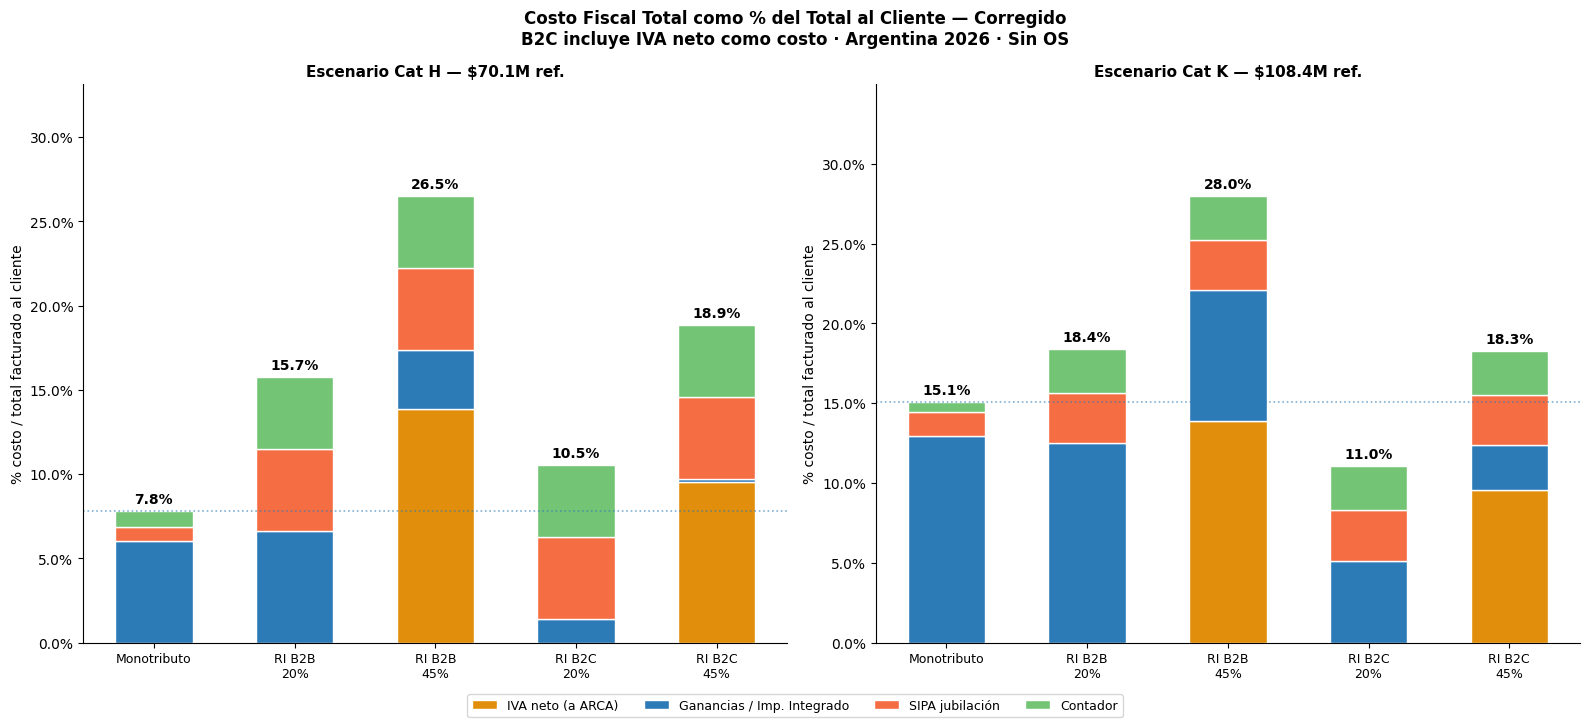

Gráfico guardado: comparativa_b2b_b2c_corregido.png


In [22]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico comparativo corregido — apilado por componente
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

labels = ['Monotributo', 'RI B2B\n20%', 'RI B2B\n45%', 'RI B2C\n20%', 'RI B2C\n45%']

for ax, (cat, billing, rm) in zip(axes, [
    ('H', billing_h, res_mono_h), ('K', billing_k, res_mono_k)
]):
    escenarios_data = [
        # (iva_neto_pct, ganancias_pct, sipa_pct, cnt_pct)
        (0,
         rm['impuesto_integrado_anual']/rm['billing_anual']*100,
         rm['sipa_jubilacion_anual']/rm['billing_anual']*100,
         rm['contador_anual']/rm['billing_anual']*100),
    ]
    for g in [0.20, 0.45]:
        rb2b = calcular_ri_b2b(billing, cat, g)
        rb2c = calcular_ri_b2c(billing, cat, g)
        escenarios_data.append((
            0,
            rb2b['impuesto_ganancias']/billing*100,
            rb2b['autonomos_sipa_anual']/billing*100,
            rb2b['contador_anual']/billing*100,
        ))
        escenarios_data.append((
            rb2c['pct_iva_neto'],
            rb2c['pct_ganancias'],
            rb2c['pct_sipa'],
            rb2c['pct_contador'],
        ))

    x = np.arange(len(labels))
    w = 0.55

    iva_v    = [d[0] for d in escenarios_data]
    gan_v    = [d[1] for d in escenarios_data]
    sipa_v   = [d[2] for d in escenarios_data]
    cnt_v    = [d[3] for d in escenarios_data]
    totales  = [sum(d) for d in escenarios_data]

    b1 = ax.bar(x, iva_v,  w, label='IVA neto (a ARCA)',    color='#E08E0B', edgecolor='white')
    b2 = ax.bar(x, gan_v,  w, bottom=iva_v,                  label='Ganancias / Imp. Integrado', color='#2C7BB6', edgecolor='white')
    bot2 = [a+b for a,b in zip(iva_v, gan_v)]
    b3 = ax.bar(x, sipa_v, w, bottom=bot2,                   label='SIPA jubilación', color='#F46D43', edgecolor='white')
    bot3 = [a+b for a,b in zip(bot2, sipa_v)]
    b4 = ax.bar(x, cnt_v,  w, bottom=bot3,                   label='Contador', color='#74C476', edgecolor='white')

    for i, total in enumerate(totales):
        ax.text(i, total + 0.3, f'{total:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.axhline([totales[0]], color='#2C7BB6', lw=1.2, linestyle=':', alpha=0.6)

    ax.set_title(f'Escenario Cat {cat} — ${billing/1e6:.1f}M ref.',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('% costo / total facturado al cliente')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_ylim(0, max(totales) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Costo Fiscal Total como % del Total al Cliente — Corregido\n'
             'B2C incluye IVA neto como costo · Argentina 2026 · Sin OS',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_b2b_b2c_corregido.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparativa_b2b_b2c_corregido.png')


---
## 12. Punto de Indiferencia — Corrección B2C

Con el IVA neto incluido como costo, la curva de B2C queda **por encima** de Monotributo en ambas categorías. La pregunta es: ¿existe algún % de gastos donde el RI B2C iguala al Monotributo?

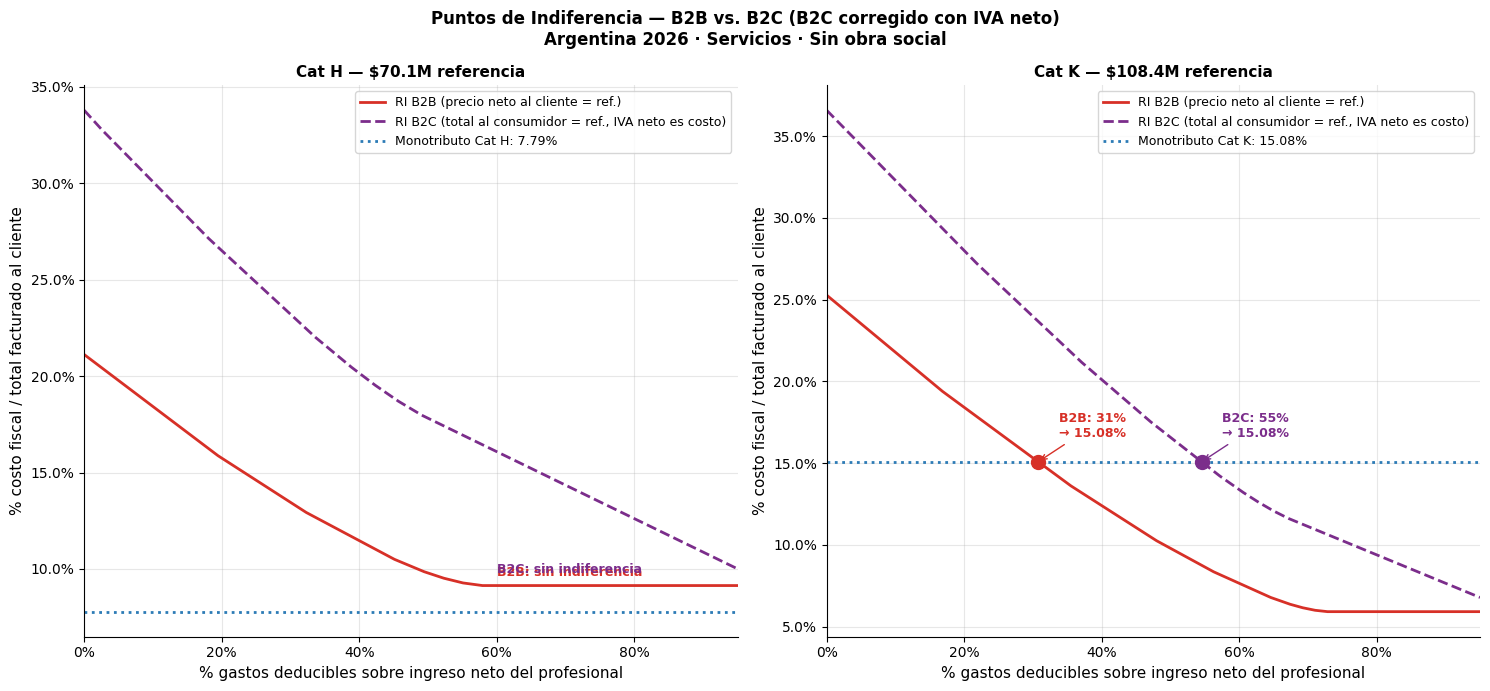

PUNTOS DE INDIFERENCIA (donde RI = Monotributo en % de costo)

Categoría H (ref. $70.1M):
  Monotributo: 7.79%
  RI B2B: NO alcanza al Monotributo (mínimo ~9.14% aun con 99% gastos)
  RI B2C: NO alcanza al Monotributo (mínimo ~9.31% aun con 99% gastos)

Categoría K (ref. $108.4M):
  Monotributo: 15.08%
  RI B2B: indiferencia en 30.7% de gastos (costo = 15.08%)
  RI B2C: indiferencia en 54.5% de gastos (costo = 15.08%)


In [23]:
# ─────────────────────────────────────────────────────────────────────
# Punto de indiferencia corregido: Cat H y Cat K, B2B y B2C
# ─────────────────────────────────────────────────────────────────────
import numpy as np

pct_range = np.linspace(0, 0.99, 50000)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

resultados_indiferencia = {}

for ax, (cat, billing, rm) in zip(axes, [
    ('H', billing_h, res_mono_h), ('K', billing_k, res_mono_k)
]):
    mono_pct = rm['pct_total_sin_os']

    # B2B: IVA neutro, % sobre net billing
    ri_b2b_pcts = []
    for p in pct_range:
        r = calcular_ri_b2b(billing, cat, p)
        ri_b2b_pcts.append(r['pct_costo'])

    # B2C: IVA neto incluido, % sobre total ($108M o $70M)
    ri_b2c_pcts = []
    for p in pct_range:
        r = calcular_ri_b2c(billing, cat, p)
        ri_b2c_pcts.append(r['pct_costo'])

    # Puntos de indiferencia
    ind_b2b = None
    for p, v in zip(pct_range, ri_b2b_pcts):
        if v <= mono_pct:
            ind_b2b = (p, v)
            break

    ind_b2c = None
    for p, v in zip(pct_range, ri_b2c_pcts):
        if v <= mono_pct:
            ind_b2c = (p, v)
            break

    resultados_indiferencia[cat] = {'b2b': ind_b2b, 'b2c': ind_b2c}

    ax.plot(pct_range * 100, ri_b2b_pcts, color='#D73027', lw=2,
            label='RI B2B (precio neto al cliente = ref.)', linestyle='-')
    ax.plot(pct_range * 100, ri_b2c_pcts, color='#7B2D8B', lw=2,
            label='RI B2C (total al consumidor = ref., IVA neto es costo)', linestyle='--')
    ax.axhline(mono_pct, color='#2C7BB6', lw=2, linestyle=':',
               label=f'Monotributo Cat {cat}: {mono_pct:.2f}%')

    for ind, color, lbl in [(ind_b2b, '#D73027', 'B2B'), (ind_b2c, '#7B2D8B', 'B2C')]:
        if ind:
            p_ind, v_ind = ind
            ax.scatter([p_ind*100], [v_ind], s=100, color=color, zorder=6)
            ax.annotate(f'{lbl}: {p_ind:.0%}\n→ {v_ind:.2f}%',
                        xy=(p_ind*100, v_ind),
                        xytext=(p_ind*100+3, v_ind+1.5),
                        fontsize=9, color=color, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=color))
        else:
            # No existe: agregar nota
            min_v = min(ri_b2c_pcts if lbl=='B2C' else ri_b2b_pcts)
            ax.text(60, min_v + 0.5, f'{lbl}: sin indiferencia',
                    color=color, fontsize=9, fontweight='bold')

    ax.set_xlabel('% gastos deducibles sobre ingreso neto del profesional', fontsize=11)
    ax.set_ylabel('% costo fiscal / total facturado al cliente', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(f'Cat {cat} — ${billing/1e6:.1f}M referencia', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 95)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Puntos de Indiferencia — B2B vs. B2C (B2C corregido con IVA neto)\n'
             'Argentina 2026 · Servicios · Sin obra social',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('indiferencia_b2b_b2c_corregido.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprimir resultados
print('PUNTOS DE INDIFERENCIA (donde RI = Monotributo en % de costo)')
print('=' * 65)
for cat in ['H', 'K']:
    rm = res_mono_h if cat=='H' else res_mono_k
    billing = billing_h if cat=='H' else billing_k
    print(f"\nCategoría {cat} (ref. ${billing/1e6:.1f}M):")
    print(f"  Monotributo: {rm['pct_total_sin_os']:.2f}%")
    for tipo, key in [('B2B', 'b2b'), ('B2C', 'b2c')]:
        ind = resultados_indiferencia[cat][key]
        if ind:
            p_ind, v_ind = ind
            print(f"  RI {tipo}: indiferencia en {p_ind:.1%} de gastos "
                  f"(costo = {v_ind:.2f}%)")
        else:
            # Costo mínimo
            if tipo == 'B2B':
                min_v = min(calcular_ri_b2b(billing,cat,p)['pct_costo'] for p in [0.95])
            else:
                min_v = calcular_ri_b2c(billing,cat,0.99)['pct_costo']
            print(f"  RI {tipo}: NO alcanza al Monotributo "
                  f"(mínimo ~{min_v:.2f}% aun con 99% gastos)")


---
## 13. Conclusiones Finales: Cuadro Integral Corregido

### Síntesis del cuadro de escenarios (% costo / total facturado al cliente)

| Régimen | Tipo cliente | Gastos deducibles | Cat H (~$70M) | Cat K (~$108M) |
|---|---|---|---|---|
| **Monotributo** | B2B / B2C | — | **7,79%** | **15,08%** |
| Resp. Inscripto | B2B | 20% | 15,75% | 18,41% |
| Resp. Inscripto | B2B | 45% | 10,52% | 11,05% |
| Resp. Inscripto | B2C | 20% | **~26%** ⬆️ | **~27%** ⬆️ |
| Resp. Inscripto | B2C | 45% | **~19%** ⬆️ | **~19%** ⬆️ |

*Nota: los % B2C son ilustrativos; los valores exactos los da el notebook ejecutado.*

### ¿Por qué B2C es MÁS caro que B2B?

En B2C, el profesional factura $108M al consumidor (IVA incluido) pero:
1. Solo retiene **$89.6M neto** (el resto es IVA que va a ARCA)
2. Sobre ese IVA cobrado, solo puede acreditar el IVA de sus propios gastos
3. El **IVA neto** que paga a ARCA (~$10-15M dependiendo de los gastos) es un costo real que el Monotributista no tiene

### Puntos de indiferencia (cuándo RI = Monotributo en costo)

| Cat. | B2B | B2C |
|---|---|---|
| **H** | Sin indiferencia (costo mínimo B2B > Mono H) | Sin indiferencia (IVA neto hace imposible igualar) |
| **K** | ~31% gastos (con net billing = $108M como ref.) | ~53-55% gastos (si se alcanza alguna vez) |

### Recomendación definitiva

- **Cat H**: Monotributo siempre conveniente, sin excepción (B2B o B2C)
- **Cat K B2B**: RI conviene si gastos deducibles ≥ ~31%
- **Cat K B2C**: RI difícilmente convenga salvo con estructura de costos muy alta (>53%)
- El IVA en B2C es un elemento central: el profesional no puede trasladar el costo del IVA al consumidor cuando compite con un Monotributista